<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=332628975" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json
import torch
import requests
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing
from kaggle_secrets import UserSecretsClient
from IPython.display import HTML

In [2]:
# A GPU will be used, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers = tickers.sort_values(by=['cik','ticker']).drop_duplicates(subset=['cik'],keep='first').set_index('cik')
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv',
                     index_col=['date','ticker'],
                     date_format='ISO8601',
                    ).replace({0.0:np.nan}).dropna()
prices.index.rename(['snapshot','ticker'],inplace=True)
prices

,,exchange,price
snapshot,ticker,,
2010-02-01,A,NYSE - Delayed Quote,20.05
2010-03-01,A,NYSE - Delayed Quote,22.50
2010-04-01,A,NYSE - Delayed Quote,24.60
2010-05-01,A,NYSE - Delayed Quote,25.94
2010-06-01,A,NYSE - Delayed Quote,23.15
...,...,...,...
2026-01-01,ZYME,NasdaqGS - Delayed Quote,26.33
2026-02-01,ZYME,NasdaqGS - Delayed Quote,22.53
2026-03-01,ZYME,NasdaqGS - Delayed Quote,23.29


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages here on Kaggle

In [6]:
keys = ['snapshot','cik','ticker','date']
snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',
                        index_col=keys,
                        usecols=keys+ml_features,
                        date_format='ISO8601',
                        dtype={'cik':str})

# We can only use ciks with a ticker symbol, because the prices dataset is per-ticker.
snapshots = snapshots[snapshots.index.get_level_values('ticker').notna()]

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].index.get_level_values('cik').unique().tolist()
snapshots = snapshots[~snapshots.index.isin(zero_asset_ciks,level='cik')]

# We ensure a window_size number of snapshots of historic data is available for each cik.
ciks_with_history = snapshots.reset_index(level='snapshot').groupby('cik')['snapshot'].count()
ciks_with_history = ciks_with_history[ciks_with_history >= window_size].index.unique().tolist()
snapshots = snapshots[snapshots.index.isin(ciks_with_history, level='cik')]

snapshots = pd.merge(snapshots, prices.drop(columns='exchange'), left_index=True, right_index=True, how='left')
snapshots

Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-07-02 0001964333 BHRB   2026-03-31   7.927711     7.063207   
           0001965040 FTRE   2026-03-31   2.683400     2.157500   
           0001968915 PHIN   2026-03-31   3.801000     2.252000   
           0001971213 SBGI   2026-03-31   5.776000     5.309000   
           0001974640 APGE   2026-03-31   1.293654          NaN   

                                         NetCashOperating_ttm  price  
snapshot   cik        ticker date                                     
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68  
           0000001800 ABT    2012-09-30              9.212610  31.43  
           0000002098 ACU    2012-09-30              0.001128  11.04  
           0000002488 AMD    2012-09-29              0.135000   2.40  
           0000002809 AEM    2012-09-30              0.722071  52.46  
...                                                       ...    ...  
2026-07-02 0001964333 BHRB   2026-03-31              0.096788    NaN  
           0001965040 FTRE   2026-03-31              0.220700    NaN  
           0001968915 PHIN   2026-03-31              0.325000    NaN  
           0001971213 SBGI   2026-03-31              0.227000    NaN  
           0001974640 APGE   2026-03-31             -0.234543    NaN  

[478940 rows x 4 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in the new column *is_created* whether a row was artificially created or not.

In [7]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates), len(unique_ciks), len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.set_index(['cik','snapshot']).sort_index().drop(columns=['date','ticker'])
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df.info()

There are 160 unique snapshots and 3250 unique ciks for a total of 520000 records.
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 520000 entries, ('0000001750', Timestamp('2013-01-01 00:00:00')) to ('0001971213', Timestamp('2026-04-01 00:00:00'))
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Assets                520000 non-null  float64
 1   Liabilities           520000 non-null  float64
 2   NetCashOperating_ttm  520000 non-null  float64
 3   price                 520000 non-null  float64
 4   is_created            520000 non-null  bool   
dtypes: bool(1), float64(4)
memory usage: 18.5+ MB


The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [8]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [9]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3250, 160, 3])
Labels shape: torch.Size([3250, 160])
Asset multiplier shape: torch.Size([3250])
Cash multiplier shape: torch.Size([160])


device(type='cpu')

Adjusted assets shape: torch.Size([3250, 160])
Adjusted cashflow shape: torch.Size([3250, 160])
Forward shape: torch.Size([3250, 160])
Epoch [1000/6000], Loss=939.21869081
Epoch [2000/6000], Loss=938.03577978
Epoch [3000/6000], Loss=937.89561083
Epoch [4000/6000], Loss=937.80196260
Epoch [5000/6000], Loss=937.69845463
Epoch [6000/6000], Loss=937.48928641


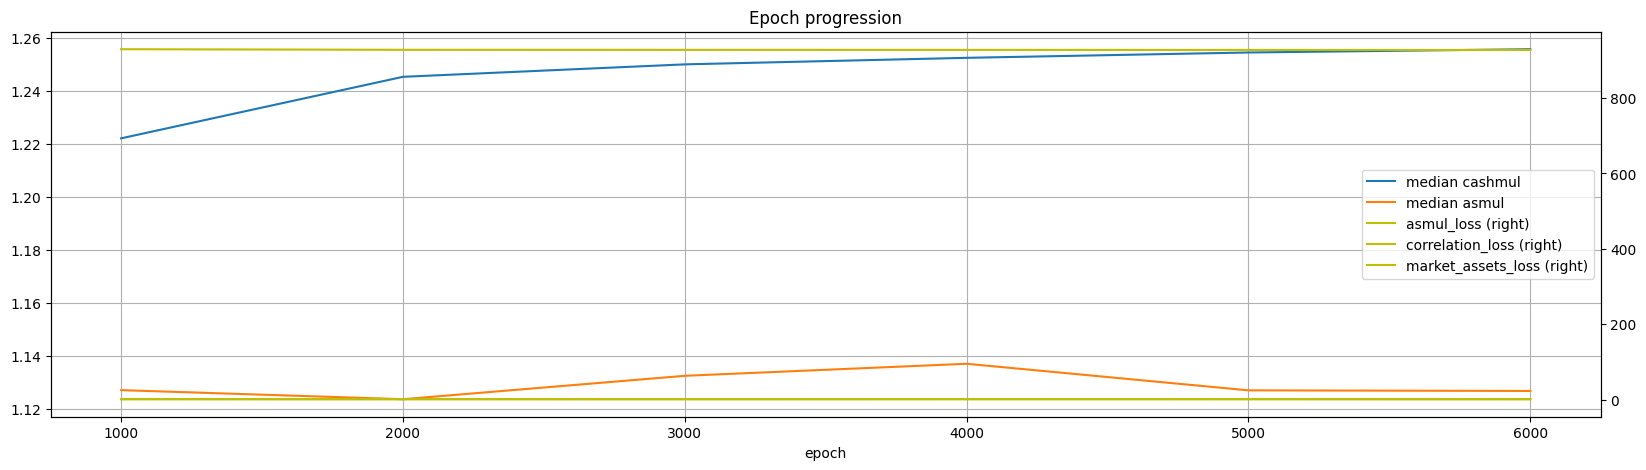

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.222130,1.127134,0.856302,929.607869,1.047801
2000,1.245334,1.123709,0.907528,928.063780,0.896721
3000,1.250029,1.132546,0.900348,927.973727,0.918406
4000,1.252495,1.137082,0.892676,927.863895,1.011308
5000,1.254506,1.127057,0.896423,927.741302,0.992927
6000,1.255741,1.126825,0.899659,927.595835,0.896860


In [10]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [11]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                       
0000001750 2013-01-01  2.1893       1.2865              0.149717  18.68   
           2013-02-01  2.1893       1.2865              0.149717  18.85   
           2013-03-01  2.1893       1.2865              0.149717  17.57   
           2013-04-01  2.2170       1.2930              0.163817  18.39   
           2013-05-01  2.2170       1.2930              0.163817  17.86   
...                       ...          ...                   ...    ...   
0001971213 2025-12-01  5.5670       5.2200              0.289000  15.76   
           2026-01-01  5.5670       5.2200              0.289000  15.30   
           2026-02-01  5.5670       5.2200              0.289000  14.51   
           2026-03-01  5.9490       5.5060              0.189000  16.34   
           2026-04-01  5.9490       5.5060              0.189000  12.94   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2013-01-01  1.022473 -1.376492  0.745915  
           2013-02-01  1.022473 -1.079412  0.790393  
           2013-03-01  1.022473 -0.974025  0.806172  
           2013-04-01  1.022473 -0.784462  0.845314  
           2013-05-01  1.022473 -0.745452  0.851704  
...                         ...       ...       ...  
0001971213 2025-12-01  2.137309  1.525759  7.119345  
           2026-01-01  2.137309  1.545558  7.125067  
           2026-02-01  2.137309  1.716544  7.174482  
           2026-03-01  2.137309  1.786021  7.546411  
           2026-04-01  2.137309  1.587359  7.508864  

[395120 rows x 7 columns]

In [12]:
%%time
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')

# The asset and cash multipliers are not available for the most recent snapshots,
# which are not part of the stock prices dataset.
# We use their latest available values in the model price formula for these recent snapshots. 
result = pd.concat([result.drop(columns=mul_columns),
                    result[mul_columns].groupby('cik',group_keys=False).apply(lambda x:x.interpolate())],
                   axis='columns')

result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(df):
    regressor = linear_model.LinearRegression().fit(X=df['model'].to_frame(), y=df[ml_label])
    return pd.Series({'hype':regressor.coef_[0], 'bias':regressor.intercept_})

result = result.merge(result[['model',ml_label]].dropna().groupby(by=['ticker','cik']).apply(line_fit),
                     left_index=True, right_index=True, how='inner')

result['model_price'] = result['model'] * result['hype'] + result['bias']

result

CPU times: user 15.6 s, sys: 111 ms, total: 15.7 s
Wall time: 15.7 s


Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-07-02 0001962481 BOF    2026-03-31   0.017174     0.011241   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   
           0001965040 FTRE   2026-03-31   2.683400     2.157500   
           0001968915 PHIN   2026-03-31   3.801000     2.252000   
           0001971213 SBGI   2026-03-31   5.776000     5.309000   

                                         NetCashOperating_ttm  price  \
snapshot   cik        ticker date                                      
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68   
           0000001800 ABT    2012-09-30              9.212610  31.43   
           0000002098 ACU    2012-09-30              0.001128  11.04   
           0000002488 AMD    2012-09-29              0.135000   2.40   
           0000002809 AEM    2012-09-30              0.722071  52.46   
...                                                       ...    ...   
2026-07-02 0001962481 BOF    2026-03-31             -0.007158    NaN   
           0001964333 BHRB   2026-03-31              0.096788    NaN   
           0001965040 FTRE   2026-03-31              0.220700    NaN   
           0001968915 PHIN   2026-03-31              0.325000    NaN   
           0001971213 SBGI   2026-03-31              0.227000    NaN   

                                            asmul   cashmul      model  \
snapshot   cik        ticker date                                        
2013-01-01 0000001750 AIR    2012-11-30  1.022473 -1.376492   0.745915   
           0000001800 ABT    2012-09-30  0.937665 -1.376492  10.389908   
           0000002098 ACU    2012-09-30  0.980650 -1.376492   0.027516   
           0000002488 AMD    2012-09-29  0.213066 -1.376492  -2.826166   
           0000002809 AEM    2012-09-30  0.422392 -1.376492  -0.618193   
...                                           ...       ...        ...   
2026-07-02 0001962481 BOF    2026-03-31  3.819985  1.587359   0.043001   
           0001964333 BHRB   2026-03-31  1.483580  1.587359   4.851826   
           0001965040 FTRE   2026-03-31  1.751021  1.587359   2.891519   
           0001968915 PHIN   2026-03-31  1.221920  1.587359   2.908411   
           0001971213 SBGI   2026-03-31  2.137309  1.587359   7.396429   

                                               hype       bias  model_price  
snapshot   cik        ticker date                                            
2013-01-01 0000001750 AIR    2012-11-30  100.460438 -66.578525     8.356448  
           0000001800 ABT    2012-09-30    2.361738  -2.304571    22.233670  
           0000002098 ACU    2012-09-30  268.019036   7.455362    14.830189  
           0000002488 AMD    2012-09-29   12.537955  49.421928    13.987591  
           0000002809 AEM    2012-09-30   27.184843  28.074050    11.268561  
...                                             ...        ...          ...  
2026-07-02 0001962481 BOF    2026-03-31   63.014549   0.638762     3.348457  
           0001964333 BHRB   2026-03-31    2.487409  50.227888    62.296364  
           0001965040 FTRE   2026-03-31    4.190804  -1.606509    10.511281  
           0001968915 PHIN   2026-03-31   -9.560792  79.845827    52.039119  
           0001971213 SBGI   2026-03-31   -1.149596  23.230864    14.727958  

[430299 rows x 10 columns]

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

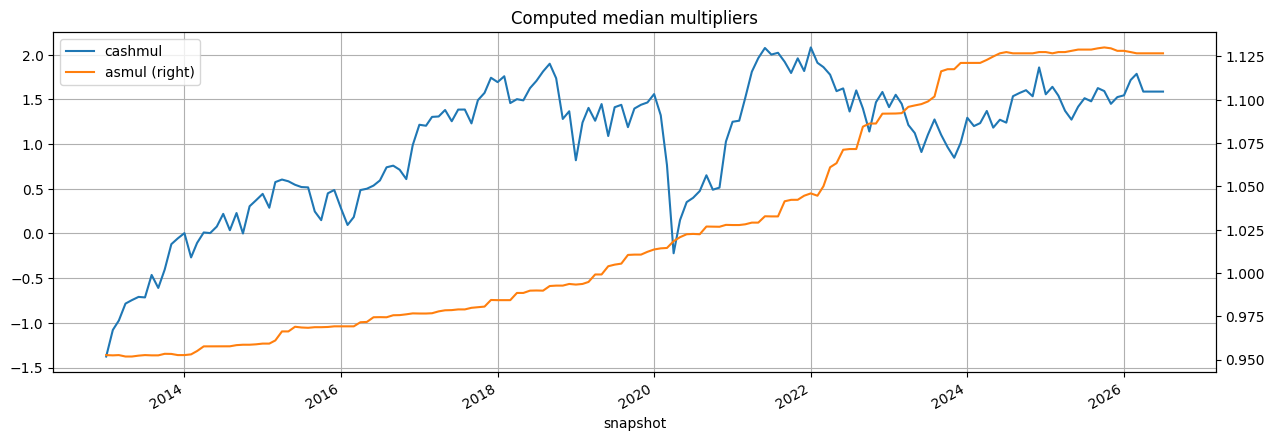

Median asset_multiplier per cik: 1.126826524734497
Median asset_multiplier per snapshot: 1.010607361793518


In [13]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

Let's examine the distribution of the achieved correlations:

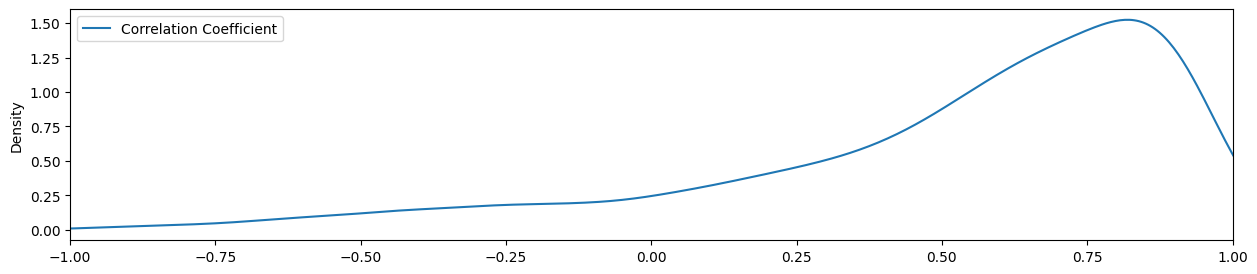

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().unstack().sum(axis='columns')/2 - 1
model_corr = model_corr.rename('Correlation Coefficient').to_frame()
model_corr.plot.density(bw_method=0.2,figsize=(15,3),xlim=(-1,1))
plt.show()

In [15]:
# Reality check for our fair price calculations:
# compute their correlation with the actual prices
result[['price','model_price']].dropna().corr()

,price,model_price
price,1.000000,0.900131
model_price,0.900131,1.000000


The [Monthly US Stock Prices](https://www.kaggle.com/datasets/vladosht/monthly-us-stock-prices) dataset is updated a few times annually, which means the stock prices used in this notebook are quite outdated most of the time. Here we attempt to obtain delayed, but still recent prices. This is not reliable, as it uses a free online service. If it works though, the plots below will be more up-to-date.

In [16]:
def get_dataframe_from_api(endpoint):
    r = requests.get(api_url.format(endpoint))
    r.raise_for_status()
    return pd.DataFrame(r.json())[['dateStamp','code','name','close','volume','change']]

try:
    api_url = UserSecretsClient().get_secret("api_url")
    api_data = pd.concat([get_dataframe_from_api(exchange) for exchange in ['NASDAQ','NYSE']])
except:
    api_data = None
    print('Failed to fetch recent prices.')

In [17]:
if api_data is not None:
    recent_prices = api_data.rename(columns={'dateStamp':'snapshot','close':'price'})
    recent_prices['ticker'] = recent_prices['code'].astype(str).str.upper().str.strip()
    recent_prices = recent_prices[recent_prices['ticker'].isin(result.index.get_level_values('ticker').unique())]
    recent_prices = recent_prices.sort_values(['ticker','snapshot']).drop_duplicates(subset=['ticker'],keep='last')
    recent_prices = recent_prices[(recent_prices['price']>0.005)&(recent_prices['volume']>0)&(recent_prices['change'].abs()>0.0)]
    recent_prices = recent_prices[recent_prices['snapshot'] == recent_prices['snapshot'].value_counts().index[0]]
    recent_prices = recent_prices[['snapshot','ticker','price','name']].set_index('ticker')

We will use the scaled percentage error as an overvaluation metric.

In [18]:
%%time
def compute_overvaluation(df):
    ticker = df.index.get_level_values('ticker').unique()[0]
    try:
        df.iloc[-1,df.columns.get_loc('price')] = recent_prices.loc[ticker]['price']
    except:
        pass
    df['overvaluation'] = (df['price'] - df['model_price']) / df['price']
    df['overvaluation'] = preprocessing.StandardScaler().fit_transform(df['overvaluation'].to_frame())
    return df
result = result.groupby('cik',group_keys=False).apply(compute_overvaluation)

CPU times: user 14.4 s, sys: 136 ms, total: 14.6 s
Wall time: 14.5 s


In [19]:
# Display a sample before the CSV export
result[result.index.isin([min(result.index.get_level_values('cik'))],level='cik')]

,,,,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,ticker,date,,,,,,,,,,,
2013-01-01,0000001750,AIR,2012-11-30,2.1893,1.2865,0.149717,18.68,1.022473,-1.376492,0.745915,100.460438,-66.578525,8.356448,2.325831
2013-02-01,0000001750,AIR,2012-11-30,2.1893,1.2865,0.149717,18.85,1.022473,-1.079412,0.790393,100.460438,-66.578525,12.824721,1.409458
2013-03-01,0000001750,AIR,2012-11-30,2.1893,1.2865,0.149717,17.57,1.022473,-0.974025,0.806172,100.460438,-66.578525,14.409821,0.859730
2013-04-01,0000001750,AIR,2013-02-28,2.2170,1.2930,0.163817,18.39,1.022473,-0.784462,0.845314,100.460438,-66.578525,18.342082,0.162620
2013-05-01,0000001750,AIR,2013-02-28,2.2170,1.2930,0.163817,17.86,1.022473,-0.745452,0.851704,100.460438,-66.578525,18.984069,-0.095148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-01,0000001750,AIR,2026-02-28,3.3325,1.6891,0.094800,109.46,1.022473,1.587359,1.868772,100.460438,-66.578525,121.159132,-0.267964
2026-05-01,0000001750,AIR,2026-02-28,3.3325,1.6891,0.094800,NaN,1.022473,1.587359,1.868772,100.460438,-66.578525,121.159132,NaN
2026-06-01,0000001750,AIR,2026-02-28,3.3325,1.6891,0.094800,NaN,1.022473,1.587359,1.868772,100.460438,-66.578525,121.159132,NaN


In [20]:
# We can now output the results for later use in other models/notebooks/datasets
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

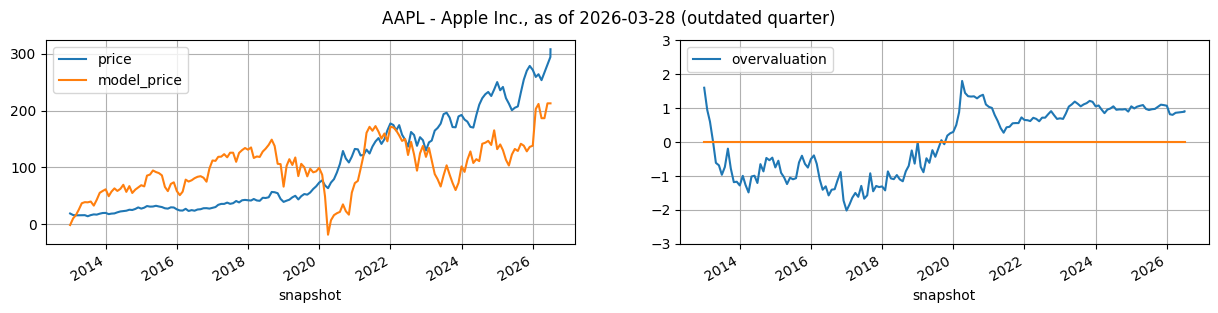

AAPL(0000320193) model_price = 0.933638 * (0.736698 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -3.060123


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-27,379.297,291.107,135.472,264.18,0.736698,1.786021,230.276351,0.933638,-3.060123,211.934723,0.797698
2026-04-01,2025-12-27,379.297,291.107,135.472,253.79,0.736698,1.587359,203.363174,0.933638,-3.060123,186.807548,0.858181
2026-05-01,2025-12-27,379.297,291.107,135.472,NaN,0.736698,1.587359,203.363174,0.933638,-3.060123,186.807548,NaN
2026-06-01,2026-03-28,371.082,264.591,140.222,NaN,0.736698,1.587359,231.367153,0.933638,-3.060123,212.953138,NaN
2026-07-01,2026-03-28,371.082,264.591,140.222,NaN,0.736698,1.587359,231.367153,0.933638,-3.060123,212.953138,NaN
2026-07-02,2026-03-28,371.082,264.591,140.222,308.22,0.736698,1.587359,231.367153,0.933638,-3.060123,212.953138,0.899461


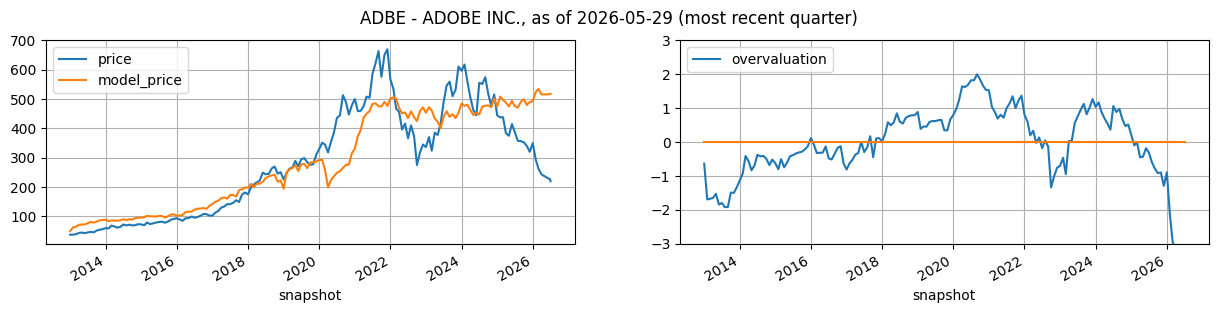

ADBE(0000796343) model_price = 13.834861 * (1.493028 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -75.721056


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-28,29.496,17.873,10.031,262.41,1.493027,1.786021,44.080918,13.834861,-75.721056,534.132303,-2.925294
2026-04-01,2026-02-27,29.704,18.271,10.507,243.08,1.493027,1.587359,42.756269,13.834861,-75.721056,515.805972,-3.205190
2026-05-01,2026-02-27,29.704,18.271,10.507,NaN,1.493027,1.587359,42.756269,13.834861,-75.721056,515.805972,NaN
2026-06-01,2026-02-27,29.704,18.271,10.507,NaN,1.493027,1.587359,42.756269,13.834861,-75.721056,515.805972,NaN
2026-07-01,2026-05-29,29.933,18.415,10.481,NaN,1.493027,1.587359,42.912901,13.834861,-75.721056,517.972954,NaN
2026-07-02,2026-05-29,29.933,18.415,10.481,219.65,1.493027,1.587359,42.912901,13.834861,-75.721056,517.972954,-3.969778


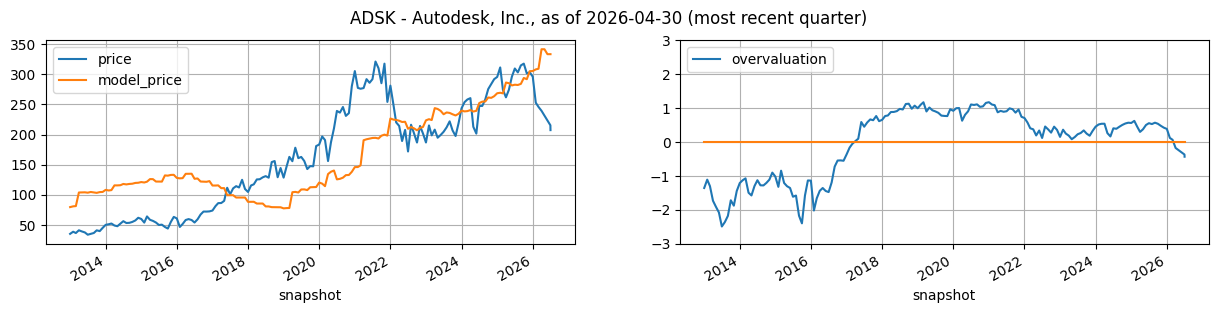

ADSK(0000769397) model_price = 7.288440 * (4.341942 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -12.715094


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-10-31,11.198,8.305,2.155,245.87,4.341942,1.786021,44.164941,7.28844,-12.715094,309.178439,0.063416
2026-04-01,2026-01-31,12.467,9.422,2.452,239.40,4.341942,1.587359,48.601193,7.28844,-12.715094,341.511801,-0.176642
2026-05-01,2026-01-31,12.467,9.422,2.452,NaN,4.341942,1.587359,48.601193,7.28844,-12.715094,341.511801,NaN
2026-06-01,2026-04-30,11.932,8.743,2.781,NaN,4.341942,1.587359,47.479496,7.28844,-12.715094,333.336374,NaN
2026-07-01,2026-04-30,11.932,8.743,2.781,NaN,4.341942,1.587359,47.479496,7.28844,-12.715094,333.336374,NaN
2026-07-02,2026-04-30,11.932,8.743,2.781,207.39,4.341942,1.587359,47.479496,7.28844,-12.715094,333.336374,-0.433337


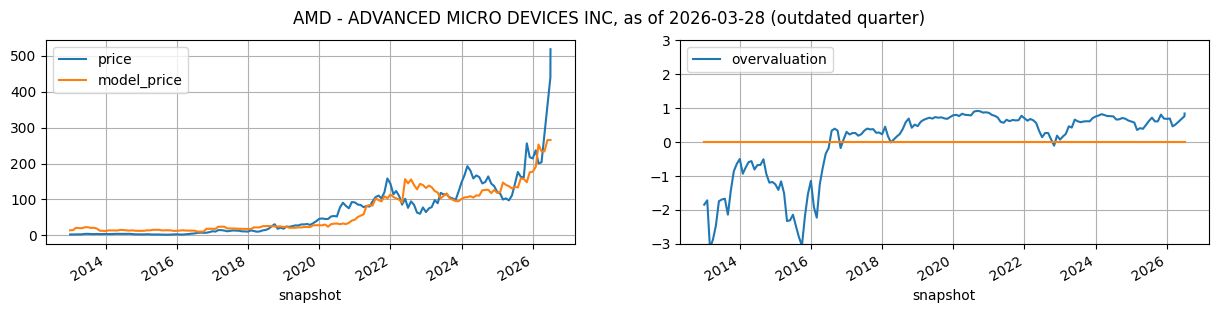

AMD(0000002488) model_price = 12.537955 * (0.213066 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +49.421928


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-27,76.926,13.927,7.709,200.21,0.213066,1.786021,16.231763,12.537955,49.421928,252.935037,0.458862
2026-04-01,2025-12-27,76.926,13.927,7.709,203.43,0.213066,1.587359,14.700275,12.537955,49.421928,233.733315,0.516591
2026-05-01,2025-12-27,76.926,13.927,7.709,NaN,0.213066,1.587359,14.700275,12.537955,49.421928,233.733315,NaN
2026-06-01,2026-03-28,79.642,15.180,9.725,NaN,0.213066,1.587359,17.226079,12.537955,49.421928,265.401725,NaN
2026-07-01,2026-03-28,79.642,15.180,9.725,NaN,0.213066,1.587359,17.226079,12.537955,49.421928,265.401725,NaN
2026-07-02,2026-03-28,79.642,15.180,9.725,518.26,0.213066,1.587359,17.226079,12.537955,49.421928,265.401725,0.838006


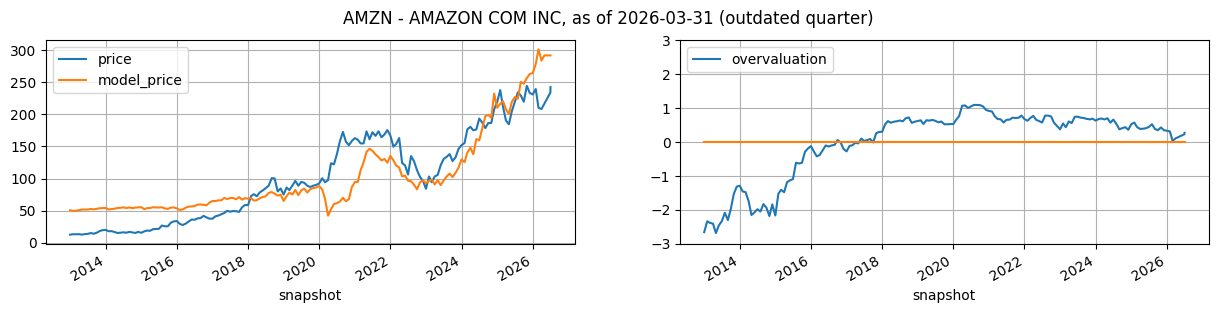

AMZN(0001018724) model_price = 0.612223 * (0.673499 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +54.998526


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,818.042,406.977,144.561750,210.00,0.673499,1.786021,402.163831,0.612223,54.998526,301.212327,0.032077
2026-04-01,2025-12-31,818.042,406.977,144.561750,208.27,0.673499,1.587359,373.444864,0.612223,54.998526,283.629926,0.106611
2026-05-01,2026-03-31,916.630,474.716,153.635917,NaN,0.673499,1.587359,386.508744,0.612223,54.998526,291.627929,NaN
2026-06-01,2026-03-31,916.630,474.716,153.635917,NaN,0.673499,1.587359,386.508744,0.612223,54.998526,291.627929,NaN
2026-07-01,2026-03-31,916.630,474.716,153.635917,NaN,0.673499,1.587359,386.508744,0.612223,54.998526,291.627929,NaN
2026-07-02,2026-03-31,916.630,474.716,153.635917,242.28,0.673499,1.587359,386.508744,0.612223,54.998526,291.627929,0.269188


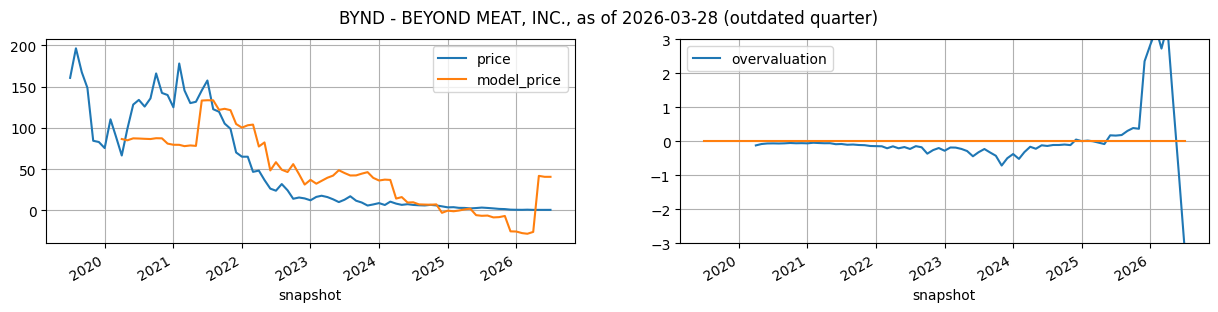

BYND(0001655210) model_price = 88.666522 * (1.749825 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +21.534670


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-09-27,0.599669,1.383734,-0.127090,0.946,1.749825,1.786021,-0.561404,88.666522,21.53467,-28.243045,2.719933
2026-04-01,2025-09-27,0.599669,1.383734,-0.127090,0.702,1.749825,1.587359,-0.536156,88.666522,21.53467,-26.004393,3.377058
2026-05-01,2025-12-31,0.614747,0.615744,-0.144931,NaN,1.749825,1.587359,0.229898,88.666522,21.53467,41.918931,NaN
2026-06-01,2026-03-28,0.579464,0.600547,-0.123813,NaN,1.749825,1.587359,0.216878,88.666522,21.53467,40.764473,NaN
2026-07-01,2026-03-28,0.579464,0.600547,-0.123813,NaN,1.749825,1.587359,0.216878,88.666522,21.53467,40.764473,NaN
2026-07-02,2026-03-28,0.579464,0.600547,-0.123813,0.715,1.749825,1.587359,0.216878,88.666522,21.53467,40.764473,-5.221486


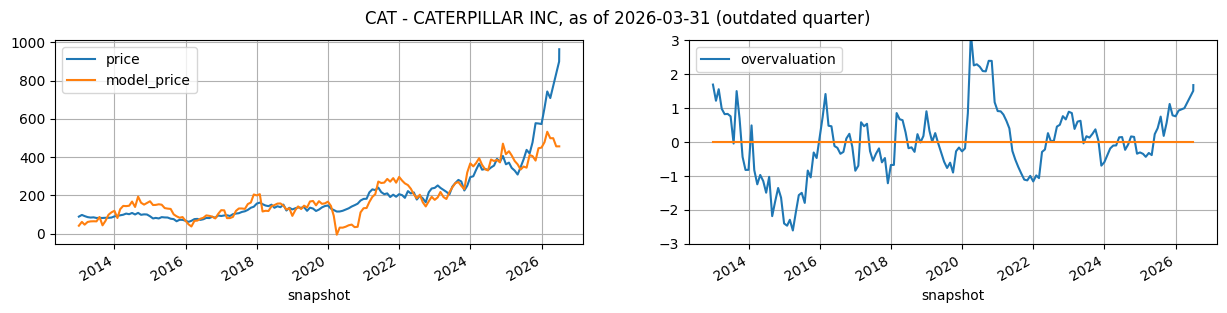

CAT(0000018230) model_price = 14.441541 * (1.398795 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -645.829295


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,98.585,77.267,11.739,742.830,1.398795,1.786021,81.599358,14.441541,-645.829295,532.591173,0.956335
2026-04-01,2025-12-31,98.585,77.267,11.739,708.460,1.398795,1.587359,79.267261,14.441541,-645.829295,498.912106,0.993932
2026-05-01,2025-12-31,98.585,77.267,11.739,NaN,1.398795,1.587359,79.267261,14.441541,-645.829295,498.912106,NaN
2026-06-01,2026-03-31,95.550,76.890,12.320,NaN,1.398795,1.587359,76.321172,14.441541,-645.829295,456.366045,NaN
2026-07-01,2026-03-31,95.550,76.890,12.320,NaN,1.398795,1.587359,76.321172,14.441541,-645.829295,456.366045,NaN
2026-07-02,2026-03-31,95.550,76.890,12.320,963.335,1.398795,1.587359,76.321172,14.441541,-645.829295,456.366045,1.673309


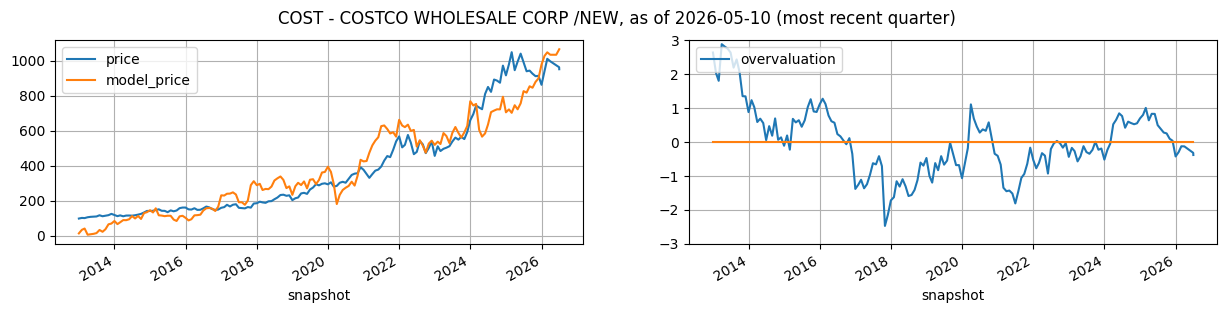

COST(0000909832) model_price = 19.717571 * (1.067563 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -180.034026


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-23,82.790,52.487,14.763,1010.79,1.067563,1.786021,62.263589,19.717571,-180.034026,1047.652673,-0.126385
2026-04-01,2026-02-15,83.639,51.552,15.011,996.43,1.067563,1.587359,61.565764,19.717571,-180.034026,1033.893258,-0.129858
2026-05-01,2026-02-15,83.639,51.552,15.011,NaN,1.067563,1.587359,61.565764,19.717571,-180.034026,1033.893258,NaN
2026-06-01,2026-02-15,83.639,51.552,15.011,NaN,1.067563,1.587359,61.565764,19.717571,-180.034026,1033.893258,NaN
2026-07-01,2026-05-10,86.430,52.921,15.000,NaN,1.067563,1.587359,63.158871,19.717571,-180.034026,1065.305475,NaN
2026-07-02,2026-05-10,86.430,52.921,15.000,951.29,1.067563,1.587359,63.158871,19.717571,-180.034026,1065.305475,-0.383053


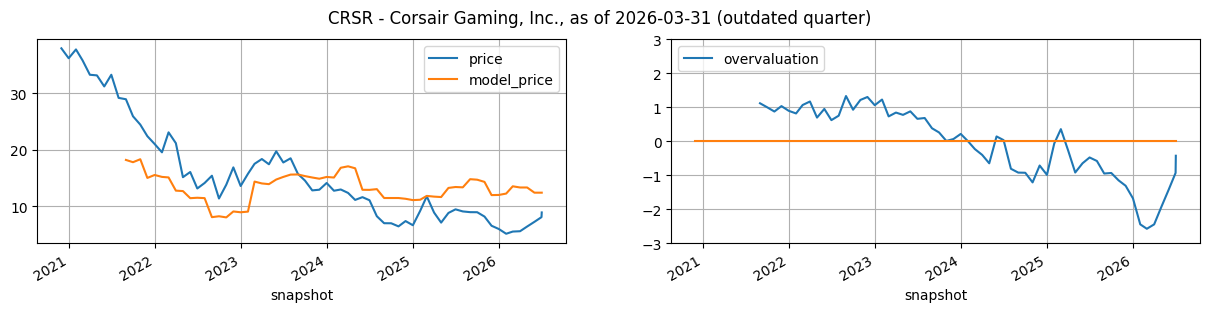

CRSR(0001743759) model_price = 20.980115 * (1.985802 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -27.586989


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,1.253784,0.620227,0.050121,5.49,1.985802,1.786021,1.959057,20.980115,-27.586989,13.514261,-2.580533
2026-04-01,2025-12-31,1.253784,0.620227,0.050121,5.55,1.985802,1.587359,1.949100,20.980115,-27.586989,13.305359,-2.451166
2026-05-01,2025-12-31,1.253784,0.620227,0.050121,NaN,1.985802,1.587359,1.949100,20.980115,-27.586989,13.305359,NaN
2026-06-01,2026-03-31,1.177340,0.529698,0.061099,NaN,1.985802,1.587359,1.905253,20.980115,-27.586989,12.385430,NaN
2026-07-01,2026-03-31,1.177340,0.529698,0.061099,NaN,1.985802,1.587359,1.905253,20.980115,-27.586989,12.385430,NaN
2026-07-02,2026-03-31,1.177340,0.529698,0.061099,8.88,1.985802,1.587359,1.905253,20.980115,-27.586989,12.385430,-0.432492


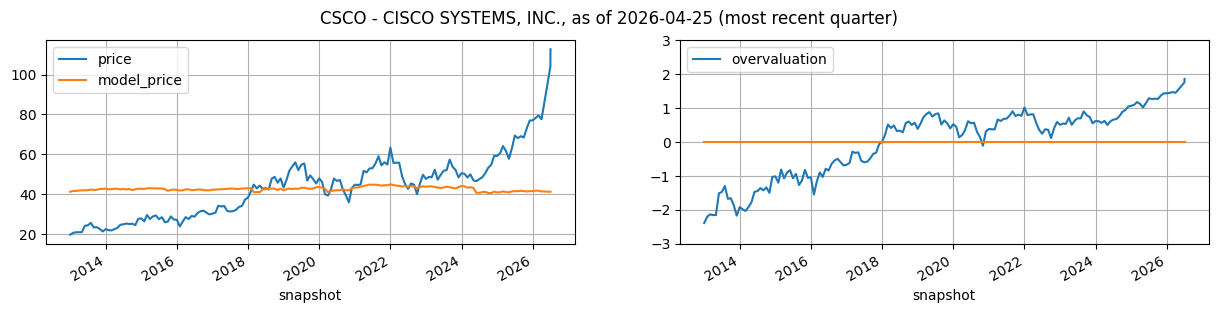

CSCO(0000858877) model_price = 0.109841 * (0.001170 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.337789


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2026-01-24,123.371,75.648,13.325,79.46,0.00117,1.786021,-51.704913,0.109841,47.337789,41.658458,1.468166
2026-04-01,2026-01-24,123.371,75.648,13.325,77.59,0.00117,1.587359,-54.352088,0.109841,47.337789,41.367689,1.446402
2026-05-01,2026-01-24,123.371,75.648,13.325,NaN,0.00117,1.587359,-54.352088,0.109841,47.337789,41.367689,NaN
2026-06-01,2026-04-25,125.546,76.685,13.025,NaN,0.00117,1.587359,-55.862750,0.109841,47.337789,41.201756,NaN
2026-07-01,2026-04-25,125.546,76.685,13.025,NaN,0.00117,1.587359,-55.862750,0.109841,47.337789,41.201756,NaN
2026-07-02,2026-04-25,125.546,76.685,13.025,112.70,0.00117,1.587359,-55.862750,0.109841,47.337789,41.201756,1.856716


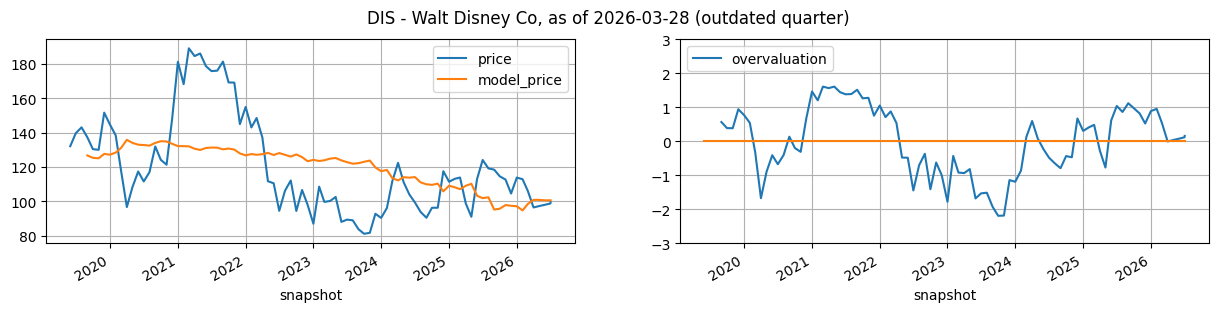

DIS(0001744489) model_price = -0.779940 * (0.951341 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +197.080094


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-27,202.089,93.613,15.631,106.04,0.951341,1.786021,126.559870,-0.77994,197.080094,98.371003,0.535778
2026-04-01,2025-12-27,202.089,93.613,15.631,96.38,0.951341,1.587359,123.454580,-0.77994,197.080094,100.792943,-0.012111
2026-05-01,2025-12-27,202.089,93.613,15.631,NaN,0.951341,1.587359,123.454580,-0.77994,197.080094,100.792943,NaN
2026-06-01,2026-03-28,205.217,96.509,15.792,NaN,0.951341,1.587359,123.789939,-0.77994,197.080094,100.531382,NaN
2026-07-01,2026-03-28,205.217,96.509,15.792,NaN,0.951341,1.587359,123.789939,-0.77994,197.080094,100.531382,NaN
2026-07-02,2026-03-28,205.217,96.509,15.792,99.47,0.951341,1.587359,123.789939,-0.77994,197.080094,100.531382,0.150789


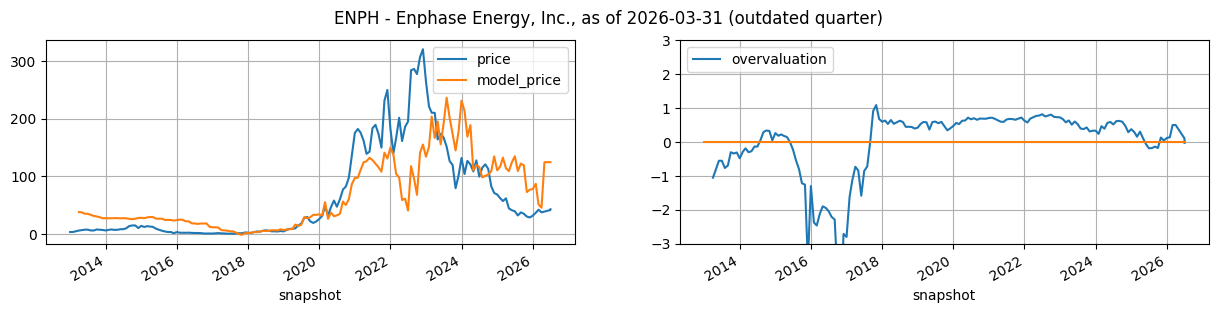

ENPH(0001463101) model_price = 210.671101 * (0.652999 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.805899


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,3.509792,2.422769,0.136540,42.27,0.652999,1.786021,0.112986,210.671101,27.805899,51.608742,0.498316
2026-04-01,2025-12-31,3.509792,2.422769,0.136540,37.81,0.652999,1.587359,0.085860,210.671101,27.805899,45.894215,0.500548
2026-05-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.652999,1.587359,0.460329,210.671101,27.805899,124.784005,NaN
2026-06-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.652999,1.587359,0.460329,210.671101,27.805899,124.784005,NaN
2026-07-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.652999,1.587359,0.460329,210.671101,27.805899,124.784005,NaN
2026-07-02,2026-03-31,2.723923,1.621571,0.190997,43.12,0.652999,1.587359,0.460329,210.671101,27.805899,124.784005,-0.026371


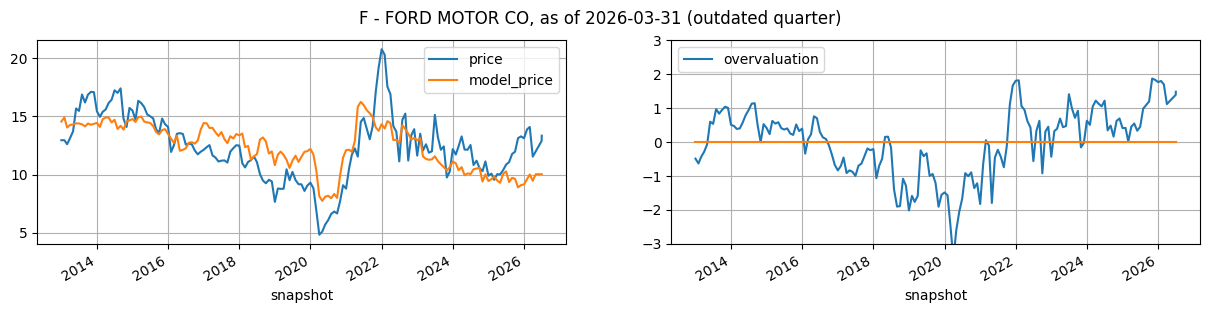

F(0000037996) model_price = 0.128678 * (0.013385 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +37.199625


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,289.160,253.208,21.282,14.090,0.013385,1.786021,-211.327542,0.128678,37.199625,10.006448,1.694013
2026-04-01,2025-12-31,289.160,253.208,21.282,11.540,0.013385,1.587359,-215.555473,0.128678,37.199625,9.462407,1.114422
2026-05-01,2026-03-31,282.434,244.981,18.919,NaN,0.013385,1.587359,-211.169428,0.128678,37.199625,10.026794,NaN
2026-06-01,2026-03-31,282.434,244.981,18.919,NaN,0.013385,1.587359,-211.169428,0.128678,37.199625,10.026794,NaN
2026-07-01,2026-03-31,282.434,244.981,18.919,NaN,0.013385,1.587359,-211.169428,0.128678,37.199625,10.026794,NaN
2026-07-02,2026-03-31,282.434,244.981,18.919,13.345,0.013385,1.587359,-211.169428,0.128678,37.199625,10.026794,1.476657


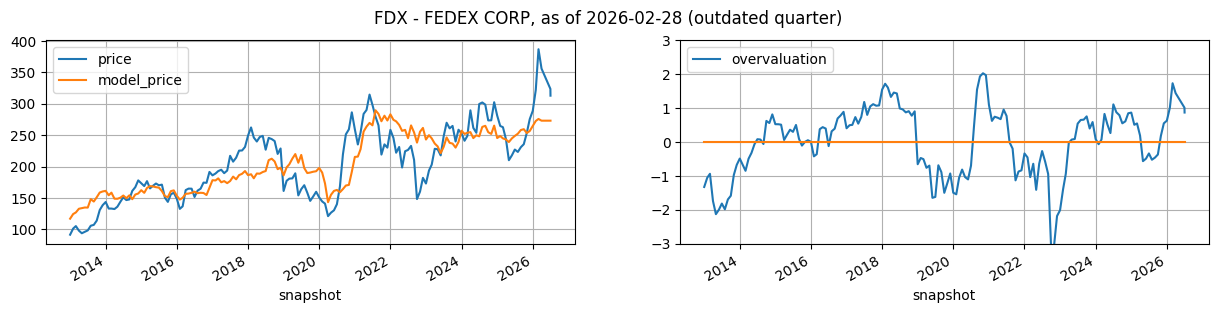

FDX(0001048911) model_price = 5.644150 * (0.911189 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +79.254783


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-30,89.181,61.041,8.198,387.00,0.911189,1.786021,34.861535,5.64415,79.254783,276.018531,1.727676
2026-04-01,2026-02-28,94.733,64.929,8.179,356.18,0.911189,1.587359,34.373662,5.64415,79.254783,273.264903,1.436048
2026-05-01,2026-02-28,94.733,64.929,8.179,NaN,0.911189,1.587359,34.373662,5.64415,79.254783,273.264903,NaN
2026-06-01,2026-02-28,94.733,64.929,8.179,NaN,0.911189,1.587359,34.373662,5.64415,79.254783,273.264903,NaN
2026-07-01,2026-02-28,94.733,64.929,8.179,NaN,0.911189,1.587359,34.373662,5.64415,79.254783,273.264903,NaN
2026-07-02,2026-02-28,94.733,64.929,8.179,313.09,0.911189,1.587359,34.373662,5.64415,79.254783,273.264903,0.865641


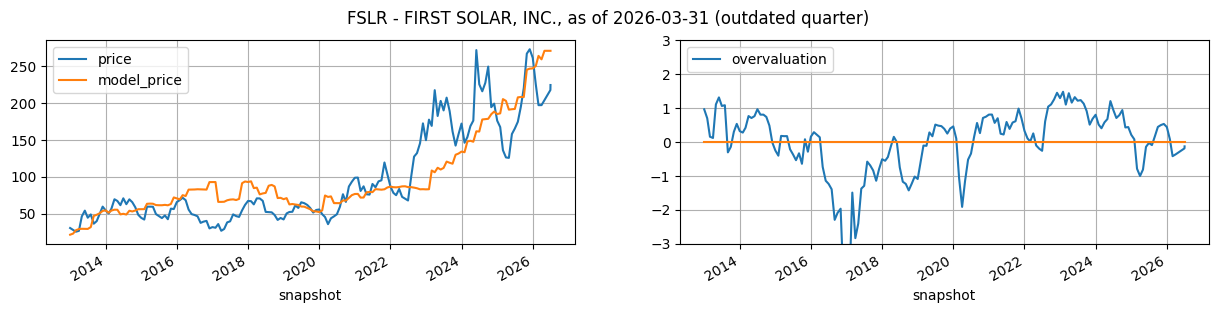

FSLR(0001274494) model_price = 11.451223 * (2.468533 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -111.375002


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,13.321310,3.783317,2.057105,197.20,2.468533,1.786021,32.774807,11.451223,-111.375002,263.936631,-0.417475
2026-04-01,2025-12-31,13.321310,3.783317,2.057105,197.26,2.468533,1.587359,32.366138,11.451223,-111.375002,259.256869,-0.364867
2026-05-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.468533,1.587359,33.374472,11.451223,-111.375002,270.803532,NaN
2026-06-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.468533,1.587359,33.374472,11.451223,-111.375002,270.803532,NaN
2026-07-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.468533,1.587359,33.374472,11.451223,-111.375002,270.803532,NaN
2026-07-02,2026-03-31,13.351097,3.472529,2.450221,224.49,2.468533,1.587359,33.374472,11.451223,-111.375002,270.803532,-0.129451


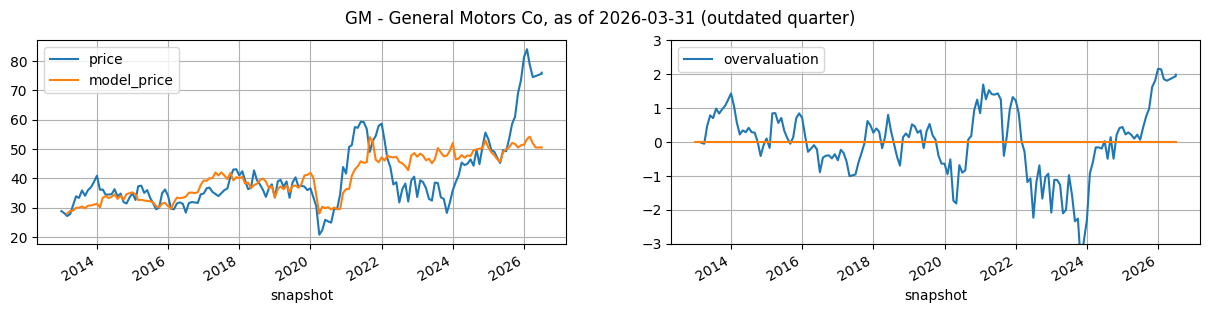

GM(0001467858) model_price = 0.423656 * (0.838163 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.266404


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,281.284,220.165,26.867,78.71,0.838163,1.786021,63.581932,0.423656,27.266404,54.203261,1.849028
2026-04-01,2025-12-31,281.284,220.165,26.867,74.50,0.838163,1.587359,58.244473,0.423656,27.266404,51.942015,1.802313
2026-05-01,2026-03-31,280.974,218.315,23.756,NaN,0.838163,1.587359,54.896368,0.423656,27.266404,50.523571,NaN
2026-06-01,2026-03-31,280.974,218.315,23.756,NaN,0.838163,1.587359,54.896368,0.423656,27.266404,50.523571,NaN
2026-07-01,2026-03-31,280.974,218.315,23.756,NaN,0.838163,1.587359,54.896368,0.423656,27.266404,50.523571,NaN
2026-07-02,2026-03-31,280.974,218.315,23.756,76.00,0.838163,1.587359,54.896368,0.423656,27.266404,50.523571,1.979202


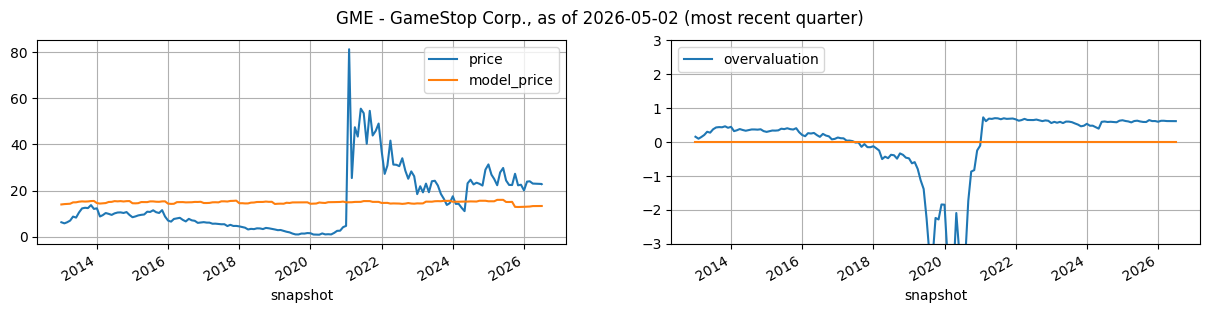

GME(0001326380) model_price = 0.837771 * (0.000857 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.599964


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-01,10.5507,5.2477,0.5835,24.03,0.000857,1.786021,-4.196513,0.837771,16.599964,13.084245,0.623801
2026-04-01,2026-01-31,10.3884,4.9440,0.6148,23.04,0.000857,1.587359,-3.959188,0.837771,16.599964,13.283070,0.614874
2026-05-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.000857,1.587359,-3.959188,0.837771,16.599964,13.283070,NaN
2026-06-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.000857,1.587359,-3.959188,0.837771,16.599964,13.283070,NaN
2026-07-01,2026-05-02,10.9743,5.1322,0.7597,NaN,0.000857,1.587359,-3.916877,0.837771,16.599964,13.318516,NaN
2026-07-02,2026-05-02,10.9743,5.1322,0.7597,22.81,0.000857,1.587359,-3.916877,0.837771,16.599964,13.318516,0.612821


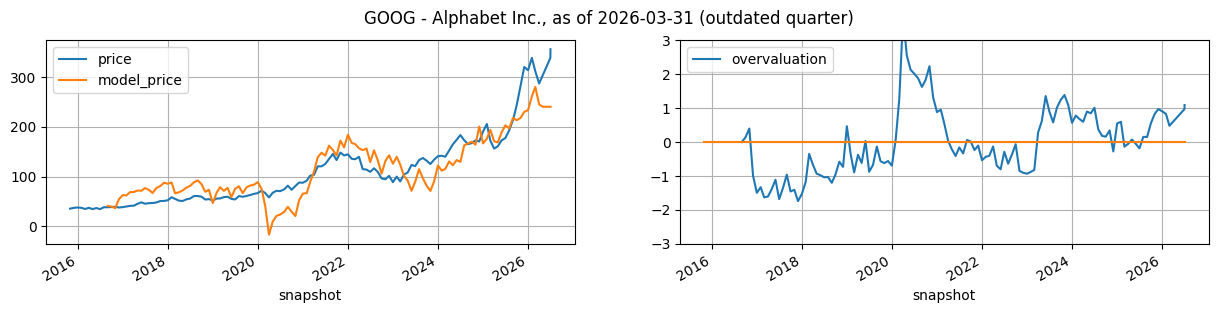

GOOG(0001652044) model_price = 1.076434 * (0.235317 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +6.467588


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,595.281,180.016,164.713,311.43,0.235318,1.786021,254.244988,1.076434,6.467588,280.145604,0.476767
2026-04-01,2025-12-31,595.281,180.016,164.713,286.86,0.235318,1.587359,221.522728,1.076434,6.467588,244.922242,0.601250
2026-05-01,2026-03-31,703.919,225.173,174.353,NaN,0.235318,1.587359,217.232295,1.076434,6.467588,240.303873,NaN
2026-06-01,2026-03-31,703.919,225.173,174.353,NaN,0.235318,1.587359,217.232295,1.076434,6.467588,240.303873,NaN
2026-07-01,2026-03-31,703.919,225.173,174.353,NaN,0.235318,1.587359,217.232295,1.076434,6.467588,240.303873,NaN
2026-07-02,2026-03-31,703.919,225.173,174.353,355.82,0.235318,1.587359,217.232295,1.076434,6.467588,240.303873,1.086895


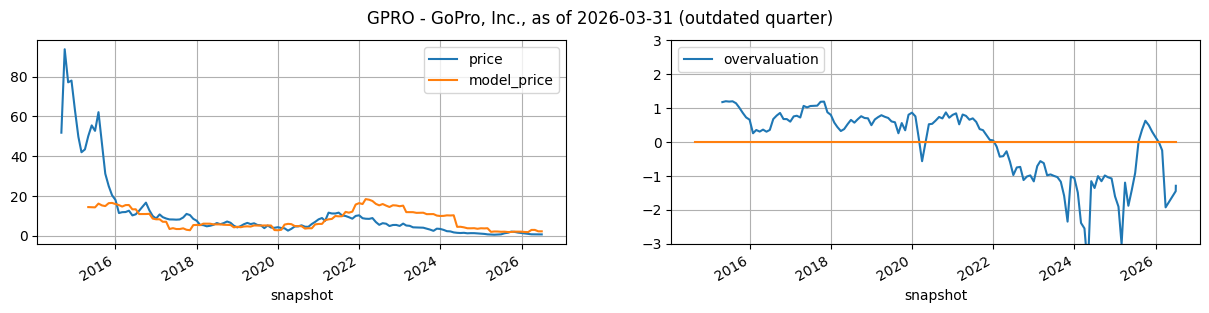

GPRO(0001500435) model_price = 15.404687 * (1.006298 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +2.263995


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-09-30,0.538608,0.458114,-0.061371,0.968,1.006298,1.786021,-0.025724,15.404687,2.263995,1.867729,-0.246107
2026-04-01,2025-12-31,0.427983,0.351433,-0.020669,0.770,1.006298,1.587359,0.046436,15.404687,2.263995,2.979332,-1.923216
2026-05-01,2025-12-31,0.427983,0.351433,-0.020669,NaN,1.006298,1.587359,0.046436,15.404687,2.263995,2.979332,NaN
2026-06-01,2026-03-31,0.381355,0.383224,-0.000101,NaN,1.006298,1.587359,0.000372,15.404687,2.263995,2.269733,NaN
2026-07-01,2026-03-31,0.381355,0.383224,-0.000101,NaN,1.006298,1.587359,0.000372,15.404687,2.263995,2.269733,NaN
2026-07-02,2026-03-31,0.381355,0.383224,-0.000101,0.724,1.006298,1.587359,0.000372,15.404687,2.263995,2.269733,-1.288377


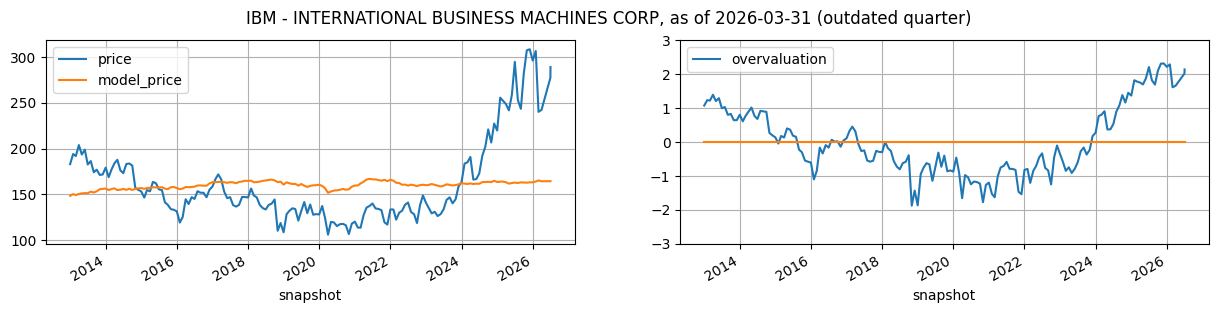

IBM(0000051143) model_price = 0.348813 * (0.679623 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +162.668363


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,151.880,119.232,13.193,240.21,0.679623,1.786021,7.552059,0.348813,162.668363,165.302619,1.609573
2026-04-01,2025-12-31,151.880,119.232,13.193,242.39,0.679623,1.587359,4.931107,0.348813,162.668363,164.388397,1.653302
2026-05-01,2026-03-31,156.229,123.255,13.992,NaN,0.679623,1.587359,5.132086,0.348813,162.668363,164.458501,NaN
2026-06-01,2026-03-31,156.229,123.255,13.992,NaN,0.679623,1.587359,5.132086,0.348813,162.668363,164.458501,NaN
2026-07-01,2026-03-31,156.229,123.255,13.992,NaN,0.679623,1.587359,5.132086,0.348813,162.668363,164.458501,NaN
2026-07-02,2026-03-31,156.229,123.255,13.992,289.12,0.679623,1.587359,5.132086,0.348813,162.668363,164.458501,2.133459


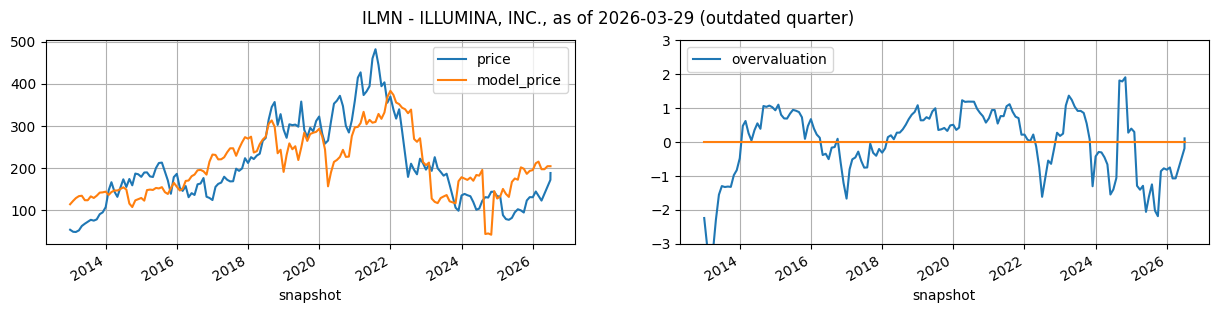

ILMN(0001110803) model_price = 84.223022 * (0.365468 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +179.138198


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-28,6.644,3.921,1.079,134.46,0.365468,1.786021,0.434284,84.223022,179.138198,215.714894,-1.071541
2026-04-01,2025-12-28,6.644,3.921,1.079,123.26,0.365468,1.587359,0.219927,84.223022,179.138198,197.661133,-1.069966
2026-05-01,2025-12-28,6.644,3.921,1.079,NaN,0.365468,1.587359,0.219927,84.223022,179.138198,197.661133,NaN
2026-06-01,2026-03-29,6.559,3.883,1.128,NaN,0.365468,1.587359,0.304643,84.223022,179.138198,204.796158,NaN
2026-07-01,2026-03-29,6.559,3.883,1.128,NaN,0.365468,1.587359,0.304643,84.223022,179.138198,204.796158,NaN
2026-07-02,2026-03-29,6.559,3.883,1.128,188.66,0.365468,1.587359,0.304643,84.223022,179.138198,204.796158,0.105589


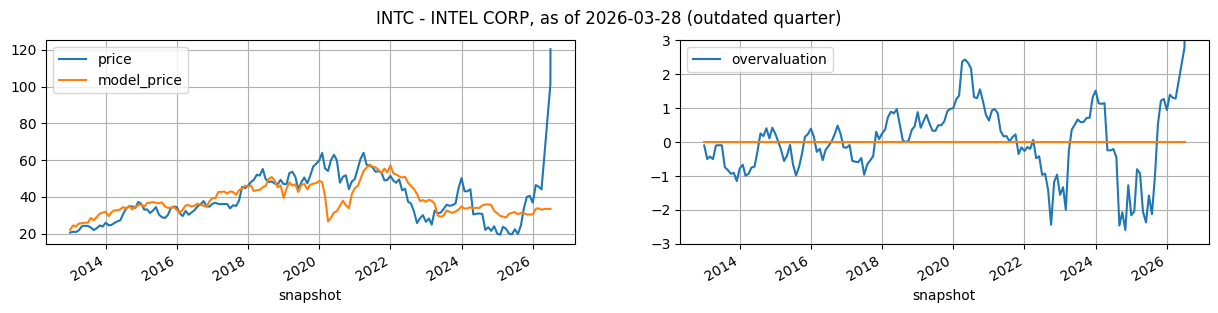

INTC(0000050863) model_price = 0.418009 * (0.407512 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +31.146939


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-27,211.429,97.148,9.697,45.610,0.407512,1.786021,6.330962,0.418009,31.146939,33.793338,1.304405
2026-04-01,2025-12-27,211.429,97.148,9.697,44.130,0.407512,1.587359,4.404534,0.418009,31.146939,32.988074,1.276319
2026-05-01,2026-03-28,205.332,93.938,9.980,NaN,0.407512,1.587359,5.579154,0.418009,31.146939,33.479075,NaN
2026-06-01,2026-03-28,205.332,93.938,9.980,NaN,0.407512,1.587359,5.579154,0.418009,31.146939,33.479075,NaN
2026-07-01,2026-03-28,205.332,93.938,9.980,NaN,0.407512,1.587359,5.579154,0.418009,31.146939,33.479075,NaN
2026-07-02,2026-03-28,205.332,93.938,9.980,120.395,0.407512,1.587359,5.579154,0.418009,31.146939,33.479075,3.273774


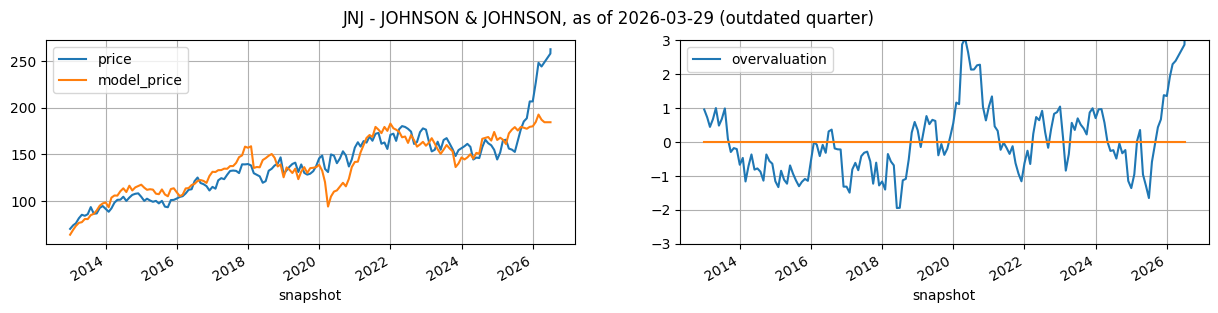

JNJ(0000200406) model_price = 1.137760 * (1.379711 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -35.848615


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-28,199.210,117.666,24.53,248.43,1.379711,1.786021,200.997338,1.13776,-35.848615,192.838197,2.287185
2026-04-01,2025-12-28,199.210,117.666,24.53,244.44,1.379711,1.587359,196.124153,1.13776,-35.848615,187.293680,2.386187
2026-05-01,2026-03-29,200.894,119.708,22.87,NaN,1.379711,1.587359,193.770570,1.13776,-35.848615,184.615866,NaN
2026-06-01,2026-03-29,200.894,119.708,22.87,NaN,1.379711,1.587359,193.770570,1.13776,-35.848615,184.615866,NaN
2026-07-01,2026-03-29,200.894,119.708,22.87,NaN,1.379711,1.587359,193.770570,1.13776,-35.848615,184.615866,NaN
2026-07-02,2026-03-29,200.894,119.708,22.87,262.97,1.379711,1.587359,193.770570,1.13776,-35.848615,184.615866,3.020744


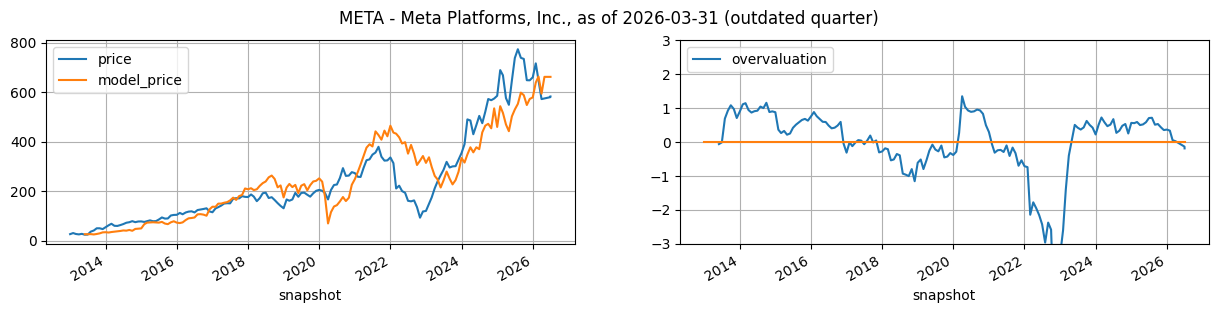

META(0001326801) model_price = 3.011440 * (0.423967 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +20.960673


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,366.021,148.778,115.8,648.18,0.423967,1.786021,213.224067,3.01144,20.960673,663.072230,0.052661
2026-04-01,2025-12-31,366.021,148.778,115.8,572.13,0.423967,1.587359,190.218974,3.01144,20.960673,593.793767,0.020851
2026-05-01,2026-03-31,395.250,151.569,124.0,NaN,0.423967,1.587359,212.836448,3.01144,20.960673,661.904939,NaN
2026-06-01,2026-03-31,395.250,151.569,124.0,NaN,0.423967,1.587359,212.836448,3.01144,20.960673,661.904939,NaN
2026-07-01,2026-03-31,395.250,151.569,124.0,NaN,0.423967,1.587359,212.836448,3.01144,20.960673,661.904939,NaN
2026-07-02,2026-03-31,395.250,151.569,124.0,582.64,0.423967,1.587359,212.836448,3.01144,20.960673,661.904939,-0.188896


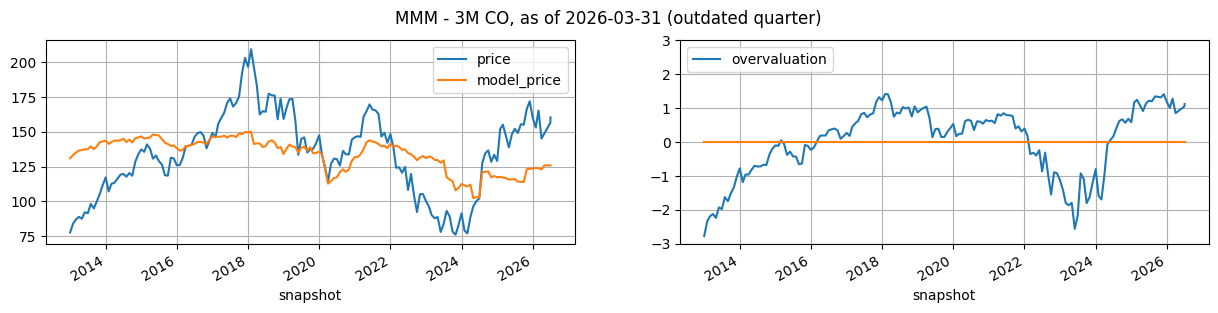

MMM(0000066740) model_price = 1.517048 * (0.001706 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +167.525625


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,37.733,33.031,2.306,165.32,0.001706,1.786021,-28.848075,1.517048,167.525625,123.761716,1.272228
2026-04-01,2025-12-31,37.733,33.031,2.306,145.23,0.001706,1.587359,-29.306190,1.517048,167.525625,123.066733,0.847353
2026-05-01,2026-03-31,35.436,32.173,2.959,NaN,0.001706,1.587359,-27.415562,1.517048,167.525625,125.934905,NaN
2026-06-01,2026-03-31,35.436,32.173,2.959,NaN,0.001706,1.587359,-27.415562,1.517048,167.525625,125.934905,NaN
2026-07-01,2026-03-31,35.436,32.173,2.959,NaN,0.001706,1.587359,-27.415562,1.517048,167.525625,125.934905,NaN
2026-07-02,2026-03-31,35.436,32.173,2.959,160.40,0.001706,1.587359,-27.415562,1.517048,167.525625,125.934905,1.115174


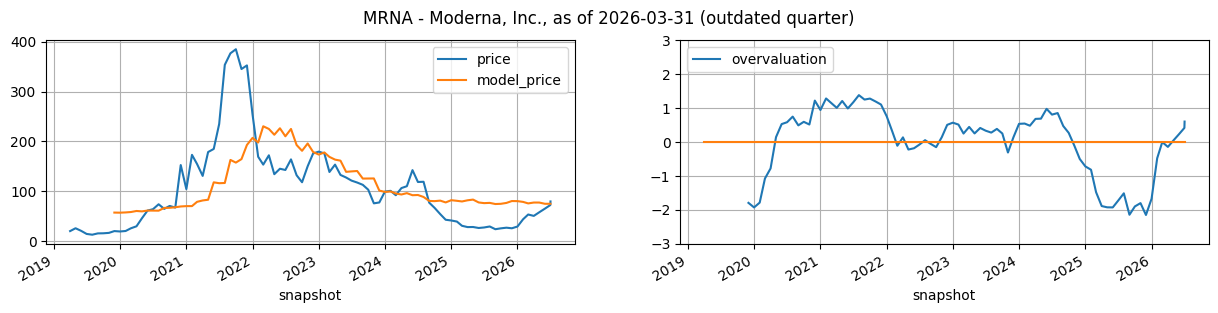

MRNA(0001682852) model_price = 4.639114 * (0.929982 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +55.239802


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,12.338,3.688,-1.873,53.57,0.929982,1.786021,4.440901,4.639114,55.239802,75.841650,-0.003170
2026-04-01,2025-12-31,12.338,3.688,-1.873,50.80,0.929982,1.587359,4.812996,4.639114,55.239802,77.567839,-0.144551
2026-05-01,2025-12-31,12.338,3.688,-1.873,NaN,0.929982,1.587359,4.812996,4.639114,55.239802,77.567839,NaN
2026-06-01,2026-03-31,11.488,4.080,-1.466,NaN,0.929982,1.587359,4.276566,4.639114,55.239802,75.079280,NaN
2026-07-01,2026-03-31,11.488,4.080,-1.466,NaN,0.929982,1.587359,4.276566,4.639114,55.239802,75.079280,NaN
2026-07-02,2026-03-31,11.488,4.080,-1.466,79.76,0.929982,1.587359,4.276566,4.639114,55.239802,75.079280,0.600152


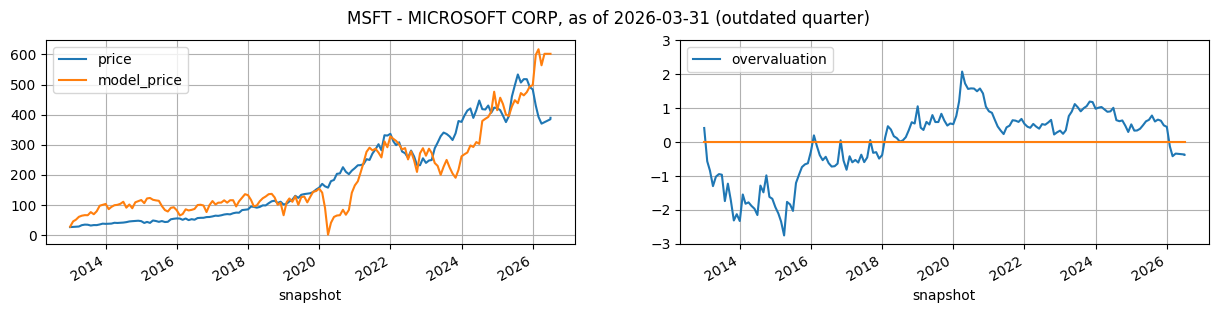

MSFT(0000789019) model_price = 1.671520 * (0.448405 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +98.136775


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,665.302,274.427,160.506,392.74,0.448405,1.786021,310.564825,1.67152,98.136775,617.252184,-0.418545
2026-04-01,2025-12-31,665.302,274.427,160.506,370.17,0.448405,1.587359,278.678337,1.67152,98.136775,563.953272,-0.341806
2026-05-01,2026-03-31,694.228,279.861,170.141,NaN,0.448405,1.587359,301.509102,1.67152,98.136775,602.115360,NaN
2026-06-01,2026-03-31,694.228,279.861,170.141,NaN,0.448405,1.587359,301.509102,1.67152,98.136775,602.115360,NaN
2026-07-01,2026-03-31,694.228,279.861,170.141,NaN,0.448405,1.587359,301.509102,1.67152,98.136775,602.115360,NaN
2026-07-02,2026-03-31,694.228,279.861,170.141,389.62,0.448405,1.587359,301.509102,1.67152,98.136775,602.115360,-0.376693


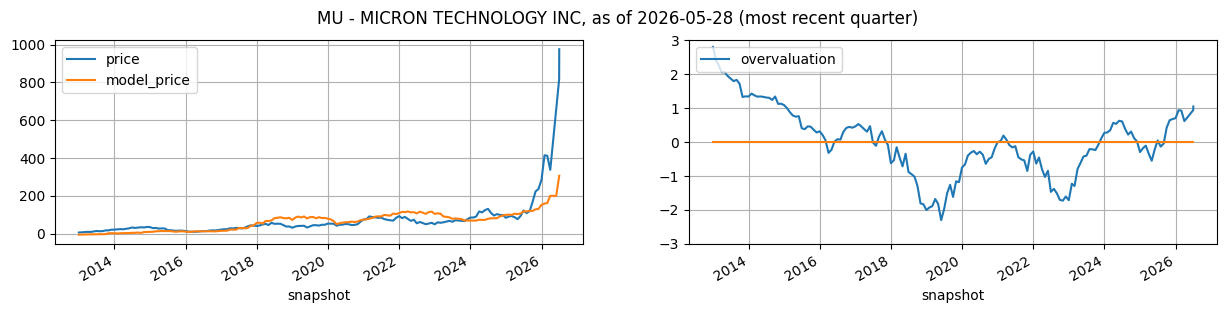

MU(0000723125) model_price = 1.652263 * (1.093101 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -15.328669


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-27,85.971,27.165,22.692,412.37,1.093101,1.786021,107.338344,1.652263,-15.328669,162.022508,0.922446
2026-04-01,2026-02-26,101.509,29.050,30.653,337.84,1.093101,1.587359,130.566861,1.652263,-15.328669,200.402128,0.613507
2026-05-01,2026-02-26,101.509,29.050,30.653,NaN,1.093101,1.587359,130.566861,1.652263,-15.328669,200.402128,NaN
2026-06-01,2026-02-26,101.509,29.050,30.653,NaN,1.093101,1.587359,130.566861,1.652263,-15.328669,200.402128,NaN
2026-07-01,2026-05-28,134.112,33.388,51.432,NaN,1.093101,1.587359,194.850952,1.652263,-15.328669,306.616356,NaN
2026-07-02,2026-05-28,134.112,33.388,51.432,975.77,1.093101,1.587359,194.850952,1.652263,-15.328669,306.616356,1.043805


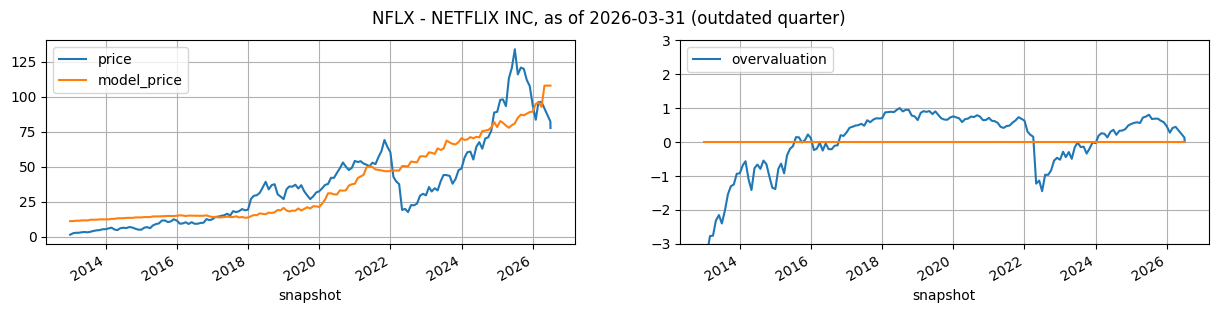

NFLX(0001065280) model_price = 1.637094 * (1.149650 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +9.134330


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,55.596993,28.981505,10.149273,96.24,1.149649,1.786021,53.062362,1.637094,9.13433,96.002425,0.411632
2026-04-01,2025-12-31,55.596993,28.981505,10.149273,96.15,1.149649,1.587359,51.046084,1.637094,9.13433,92.701588,0.444825
2026-05-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.149649,1.587359,60.337928,1.637094,9.13433,107.913213,NaN
2026-06-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.149649,1.587359,60.337928,1.637094,9.13433,107.913213,NaN
2026-07-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.149649,1.587359,60.337928,1.637094,9.13433,107.913213,NaN
2026-07-02,2026-03-31,61.015914,29.889515,12.650279,77.59,1.149649,1.587359,60.337928,1.637094,9.13433,107.913213,0.020741


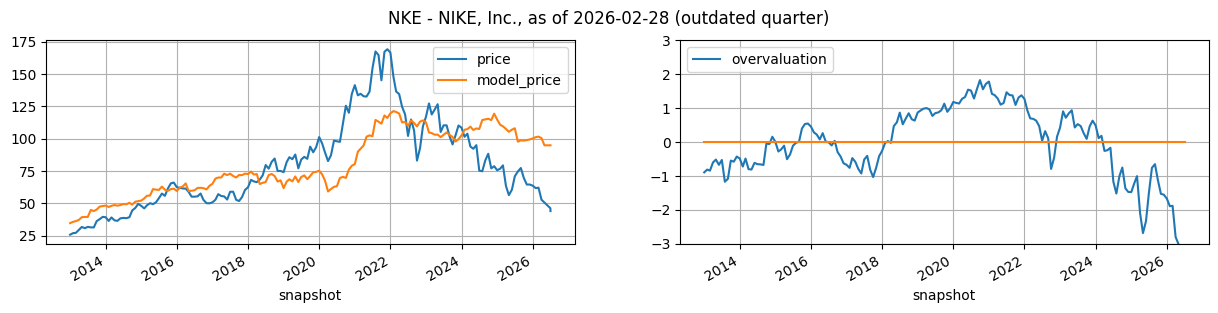

NKE(0000320187) model_price = 1.943303 * (1.954766 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -6.428794


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-30,37.787,23.702,3.056,62.180,1.954766,1.786021,55.620825,1.943303,-6.428794,101.659330,-1.878288
2026-04-01,2025-11-30,37.787,23.702,3.056,52.820,1.954766,1.587359,55.013713,1.943303,-6.428794,100.479528,-2.794375
2026-05-01,2026-02-28,37.064,22.974,1.694,NaN,1.954766,1.587359,52.166435,1.943303,-6.428794,94.946402,NaN
2026-06-01,2026-02-28,37.064,22.974,1.694,NaN,1.954766,1.587359,52.166435,1.943303,-6.428794,94.946402,NaN
2026-07-01,2026-02-28,37.064,22.974,1.694,NaN,1.954766,1.587359,52.166435,1.943303,-6.428794,94.946402,NaN
2026-07-02,2026-02-28,37.064,22.974,1.694,44.075,1.954766,1.587359,52.166435,1.943303,-6.428794,94.946402,-3.657422


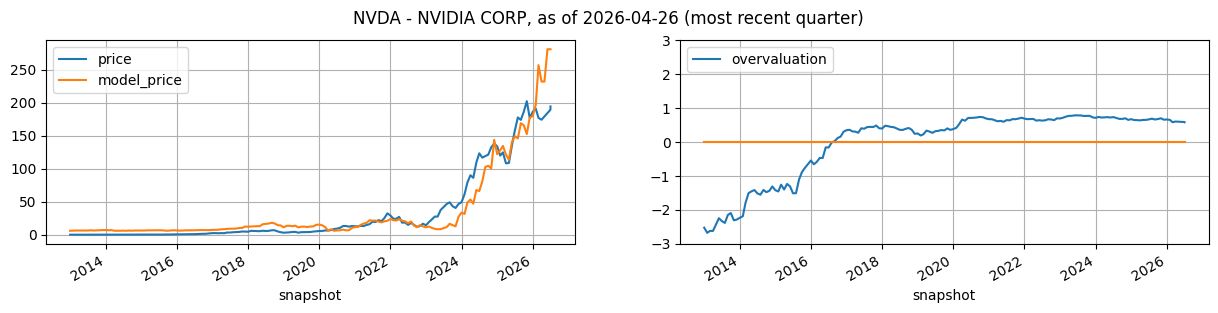

NVDA(0001045810) model_price = 1.215774 * (0.348190 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +6.635811


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2026-01-25,206.803,49.51,102.718,177.19,0.34819,1.786021,205.953237,1.215774,6.635811,257.028367,0.581148
2026-04-01,2026-01-25,206.803,49.51,102.718,174.40,0.34819,1.587359,185.547044,1.215774,6.635811,232.219052,0.600881
2026-05-01,2026-01-25,206.803,49.51,102.718,NaN,0.34819,1.587359,185.547044,1.215774,6.635811,232.219052,NaN
2026-06-01,2026-04-26,259.474,64.00,125.648,NaN,0.34819,1.587359,225.794693,1.215774,6.635811,281.151090,NaN
2026-07-01,2026-04-26,259.474,64.00,125.648,NaN,0.34819,1.587359,225.794693,1.215774,6.635811,281.151090,NaN
2026-07-02,2026-04-26,259.474,64.00,125.648,194.51,0.34819,1.587359,225.794693,1.215774,6.635811,281.151090,0.582001


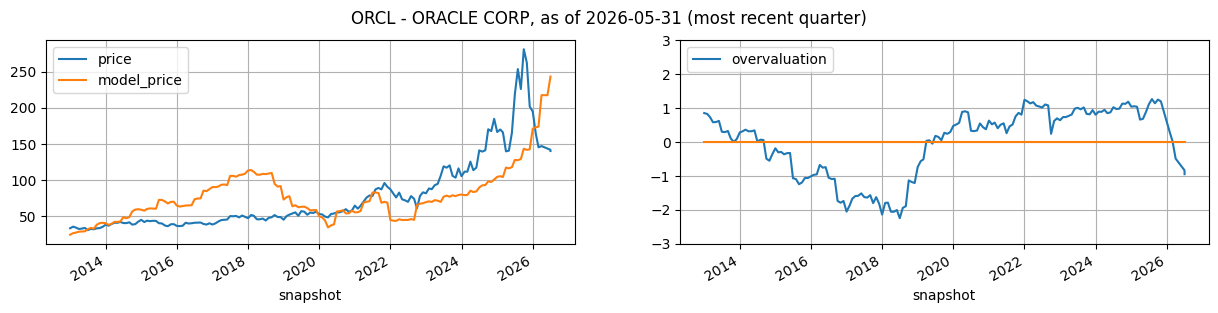

ORCL(0001341439) model_price = 0.529806 * (2.892057 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -68.380036


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-30,204.984,175.033,22.296,145.40,2.892057,1.786021,457.613630,0.529806,-68.380036,174.066184,0.016600
2026-04-01,2026-02-28,245.240,206.745,23.514,147.11,2.892057,1.587359,539.828323,0.529806,-68.380036,217.623980,-0.488750
2026-05-01,2026-02-28,245.240,206.745,23.514,NaN,2.892057,1.587359,539.828323,0.529806,-68.380036,217.623980,NaN
2026-06-01,2026-02-28,245.240,206.745,23.514,NaN,2.892057,1.587359,539.828323,0.529806,-68.380036,217.623980,NaN
2026-07-01,2026-05-31,261.759,219.251,31.977,NaN,2.892057,1.587359,588.530039,0.529806,-68.380036,243.426418,NaN
2026-07-02,2026-05-31,261.759,219.251,31.977,140.30,2.892057,1.587359,588.530039,0.529806,-68.380036,243.426418,-0.946712


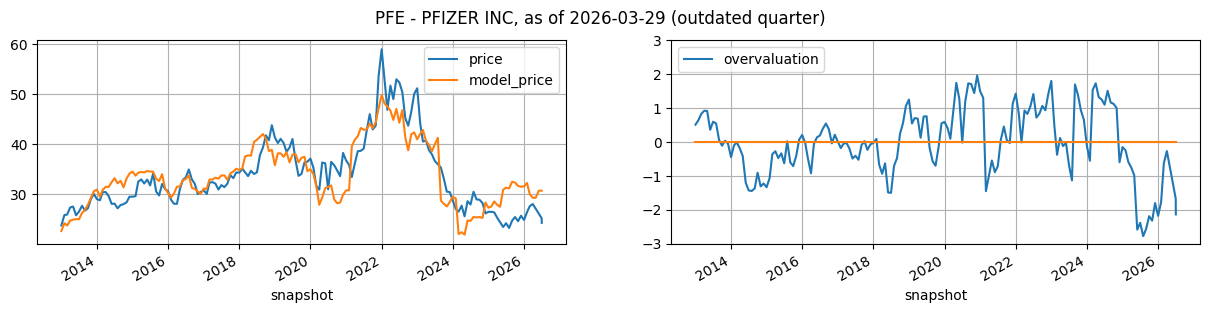

PFE(0000078003) model_price = 0.308928 * (0.010066 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +60.532850


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,208.160,121.684,11.704,27.650,0.010066,1.786021,-98.685060,0.308928,60.53285,30.046252,-0.625070
2026-04-01,2025-12-31,208.160,121.684,11.704,28.080,0.010066,1.587359,-101.010203,0.308928,60.53285,29.327949,-0.267868
2026-05-01,2025-12-31,208.160,121.684,11.704,NaN,0.010066,1.587359,-101.010203,0.308928,60.53285,29.327949,NaN
2026-06-01,2026-03-29,207.618,117.517,11.984,NaN,0.010066,1.587359,-96.404198,0.308928,60.53285,30.750874,NaN
2026-07-01,2026-03-29,207.618,117.517,11.984,NaN,0.010066,1.587359,-96.404198,0.308928,60.53285,30.750874,NaN
2026-07-02,2026-03-29,207.618,117.517,11.984,24.315,0.010066,1.587359,-96.404198,0.308928,60.53285,30.750874,-2.131200


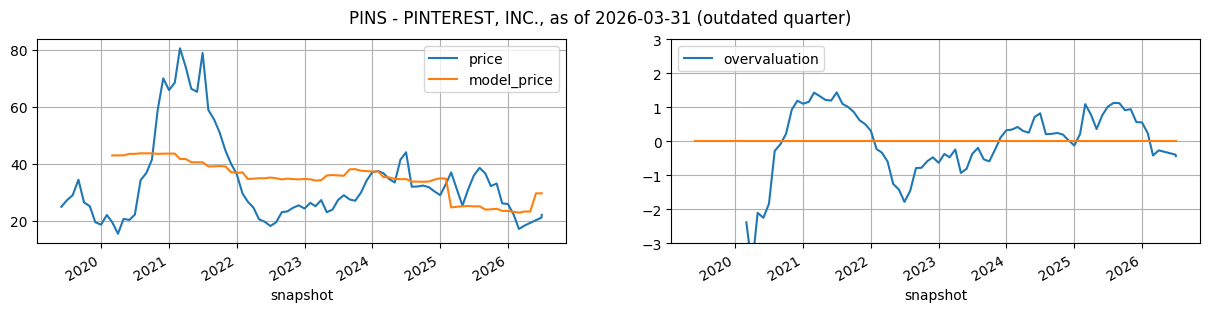

PINS(0001506293) model_price = -1.531631 * (3.618679 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +55.667212


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,5.492132,0.746894,1.284264,17.13,3.618679,1.786021,21.421092,-1.531631,55.667212,22.858010,-0.424924
2026-04-01,2025-12-31,5.492132,0.746894,1.284264,18.34,3.618679,1.587359,21.165957,-1.531631,55.667212,23.248782,-0.274001
2026-05-01,2025-12-31,5.492132,0.746894,1.284264,NaN,3.618679,1.587359,21.165957,-1.531631,55.667212,23.248782,NaN
2026-06-01,2026-03-31,4.645279,1.794695,1.248581,NaN,3.618679,1.587359,16.997025,-1.531631,55.667212,29.634047,NaN
2026-07-01,2026-03-31,4.645279,1.794695,1.248581,NaN,3.618679,1.587359,16.997025,-1.531631,55.667212,29.634047,NaN
2026-07-02,2026-03-31,4.645279,1.794695,1.248581,22.07,3.618679,1.587359,16.997025,-1.531631,55.667212,29.634047,-0.443798


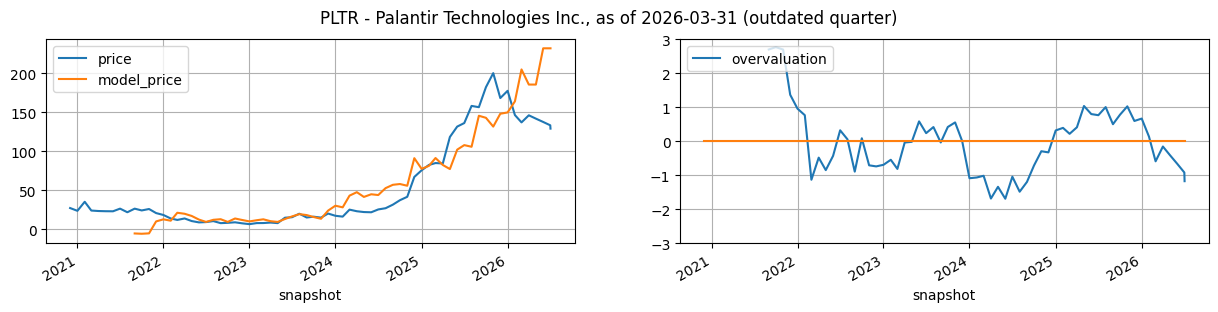

PLTR(0001321655) model_price = 45.799927 * (0.245296 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.077385


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,8.900392,1.513124,2.134473,137.19,0.245296,1.786021,4.482320,45.799927,-0.077385,205.212532,-0.596318
2026-04-01,2025-12-31,8.900392,1.513124,2.134473,146.28,0.245296,1.587359,4.058280,45.799927,-0.077385,185.791564,-0.161204
2026-05-01,2025-12-31,8.900392,1.513124,2.134473,NaN,0.245296,1.587359,4.058280,45.799927,-0.077385,185.791564,NaN
2026-06-01,2026-03-31,10.199183,1.749520,2.723375,NaN,0.245296,1.587359,5.075271,45.799927,-0.077385,232.369678,NaN
2026-07-01,2026-03-31,10.199183,1.749520,2.723375,NaN,0.245296,1.587359,5.075271,45.799927,-0.077385,232.369678,NaN
2026-07-02,2026-03-31,10.199183,1.749520,2.723375,129.17,0.245296,1.587359,5.075271,45.799927,-0.077385,232.369678,-1.180635


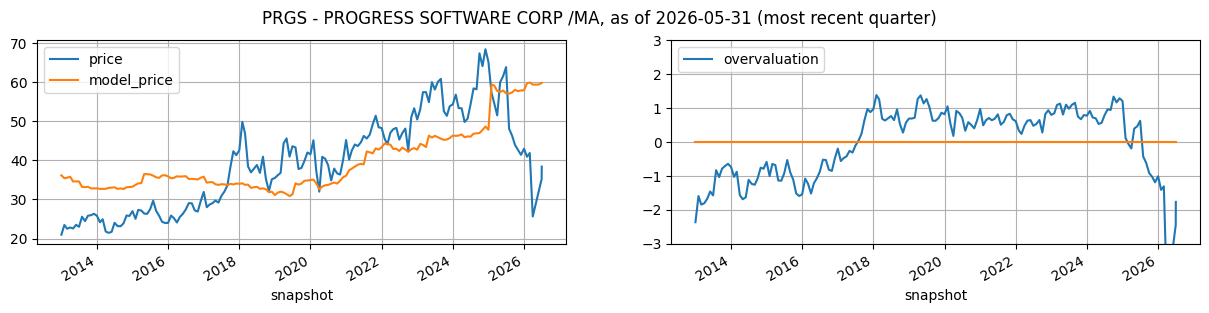

PRGS(0000876167) model_price = 12.423284 * (2.016061 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +17.725488


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-30,2.457658,1.979309,0.235187,41.88,2.016061,1.786021,3.395527,12.423284,17.725488,59.909088,-1.305115
2026-04-01,2026-02-28,2.394774,1.895979,0.264866,25.65,2.016061,1.587359,3.352468,12.423284,17.725488,59.374147,-4.489710
2026-05-01,2026-02-28,2.394774,1.895979,0.264866,NaN,2.016061,1.587359,3.352468,12.423284,17.725488,59.374147,NaN
2026-06-01,2026-02-28,2.394774,1.895979,0.264866,NaN,2.016061,1.587359,3.352468,12.423284,17.725488,59.374147,NaN
2026-07-01,2026-05-31,2.345623,1.839540,0.313707,NaN,2.016061,1.587359,3.387344,12.423284,17.725488,59.807420,NaN
2026-07-02,2026-05-31,2.345623,1.839540,0.313707,38.40,2.016061,1.587359,3.387344,12.423284,17.725488,59.807420,-1.762448


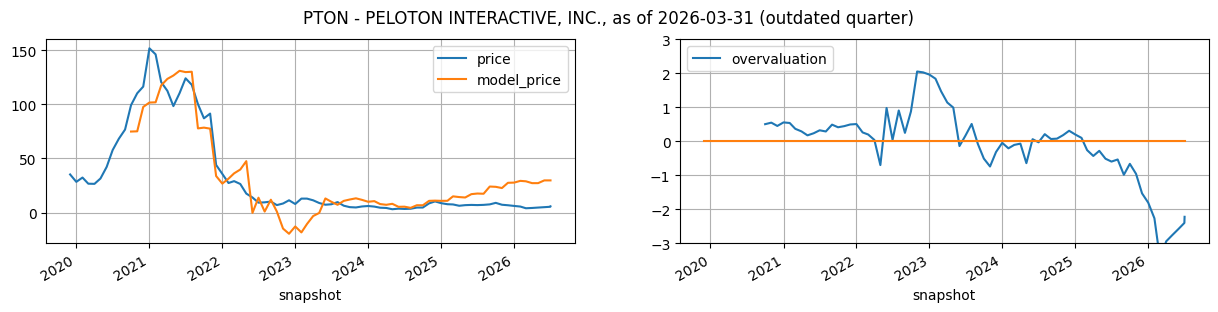

PTON(0001639825) model_price = 23.868857 * (1.458857 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.252769


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,2.1646,2.4913,0.3576,4.02,1.458858,1.786021,1.305224,23.868857,-2.252769,28.901441,-3.472585
2026-04-01,2025-12-31,2.1646,2.4913,0.3576,4.29,1.458858,1.587359,1.234183,23.868857,-2.252769,27.205759,-2.949816
2026-05-01,2025-12-31,2.1646,2.4913,0.3576,NaN,1.458858,1.587359,1.234183,23.868857,-2.252769,27.205759,NaN
2026-06-01,2026-03-31,2.0174,2.2593,0.4136,NaN,1.458858,1.587359,1.340331,23.868857,-2.252769,29.739397,NaN
2026-07-01,2026-03-31,2.0174,2.2593,0.4136,NaN,1.458858,1.587359,1.340331,23.868857,-2.252769,29.739397,NaN
2026-07-02,2026-03-31,2.0174,2.2593,0.4136,5.75,1.458858,1.587359,1.340331,23.868857,-2.252769,29.739397,-2.228571


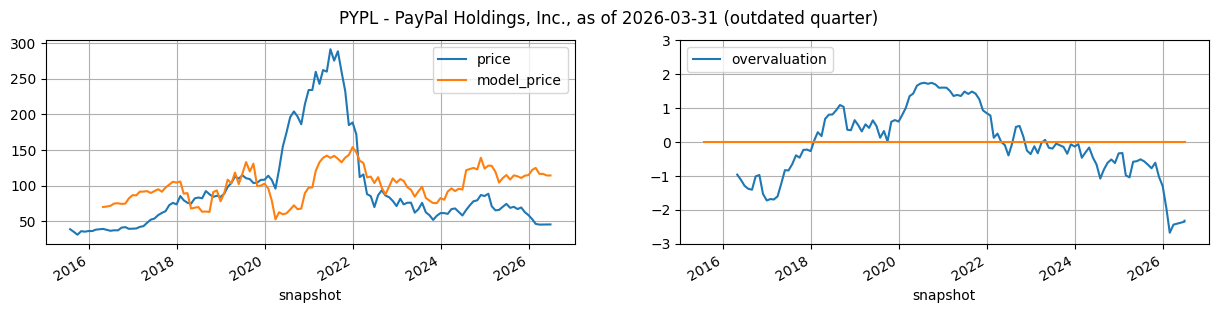

PYPL(0001633917) model_price = 6.613341 * (0.833480 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +3.406767


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,80.173,59.917,6.416,46.210,0.83348,1.786021,18.364743,6.613341,3.406767,124.859073,-2.669634
2026-04-01,2025-12-31,80.173,59.917,6.416,45.230,0.83348,1.587359,17.090126,6.613341,3.406767,116.429595,-2.431104
2026-05-01,2025-12-31,80.173,59.917,6.416,NaN,0.83348,1.587359,17.090126,6.613341,3.406767,116.429595,NaN
2026-06-01,2026-03-31,80.546,60.522,6.390,NaN,0.83348,1.587359,16.754743,6.613341,3.406767,114.211592,NaN
2026-07-01,2026-03-31,80.546,60.522,6.390,NaN,0.83348,1.587359,16.754743,6.613341,3.406767,114.211592,NaN
2026-07-02,2026-03-31,80.546,60.522,6.390,45.455,0.83348,1.587359,16.754743,6.613341,3.406767,114.211592,-2.316270


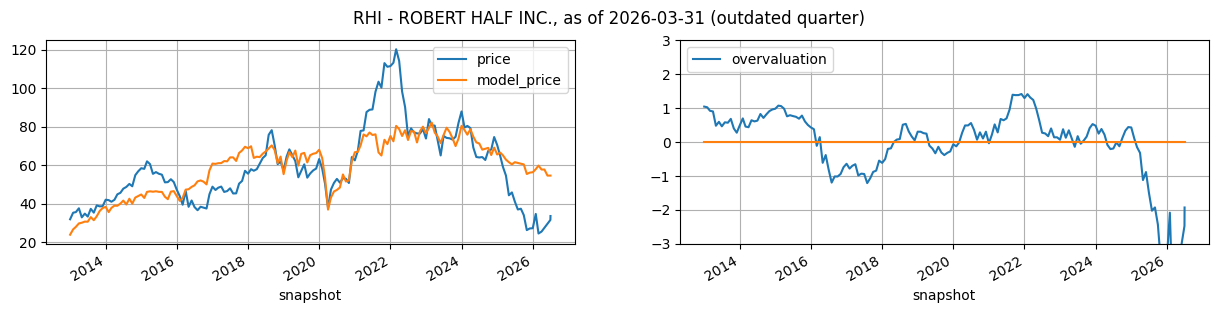

RHI(0000315213) model_price = 32.425697 * (0.794259 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +18.923756


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,2.856276,1.580419,0.319965,24.42,0.794259,1.786021,1.259668,32.425697,18.923756,59.769356,-4.690560
2026-04-01,2025-12-31,2.856276,1.580419,0.319965,25.40,0.794259,1.587359,1.196103,32.425697,18.923756,57.708217,-4.098565
2026-05-01,2025-12-31,2.856276,1.580419,0.319965,NaN,0.794259,1.587359,1.196103,32.425697,18.923756,57.708217,NaN
2026-06-01,2026-03-31,2.703702,1.472471,0.266973,NaN,0.794259,1.587359,1.098750,32.425697,18.923756,54.551492,NaN
2026-07-01,2026-03-31,2.703702,1.472471,0.266973,NaN,0.794259,1.587359,1.098750,32.425697,18.923756,54.551492,NaN
2026-07-02,2026-03-31,2.703702,1.472471,0.266973,33.51,0.794259,1.587359,1.098750,32.425697,18.923756,54.551492,-1.927024


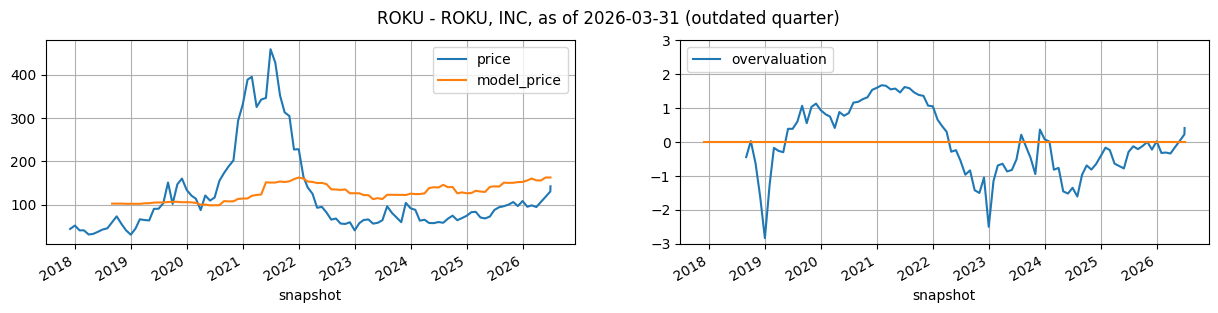

ROKU(0001428439) model_price = 45.235459 * (0.497782 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +101.901287


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,4.433483,1.775538,0.483718,98.41,0.497782,1.786021,1.295303,45.235459,101.901287,160.494897,-0.310336
2026-04-01,2025-12-31,4.433483,1.775538,0.483718,94.62,0.497782,1.587359,1.199206,45.235459,101.901287,156.147927,-0.339029
2026-05-01,2025-12-31,4.433483,1.775538,0.483718,NaN,0.497782,1.587359,1.199206,45.235459,101.901287,156.147927,NaN
2026-06-01,2026-03-31,4.352634,1.681570,0.544126,NaN,0.497782,1.587359,1.348818,45.235459,101.901287,162.915693,NaN
2026-07-01,2026-03-31,4.352634,1.681570,0.544126,NaN,0.497782,1.587359,1.348818,45.235459,101.901287,162.915693,NaN
2026-07-02,2026-03-31,4.352634,1.681570,0.544126,142.50,0.497782,1.587359,1.348818,45.235459,101.901287,162.915693,0.411454


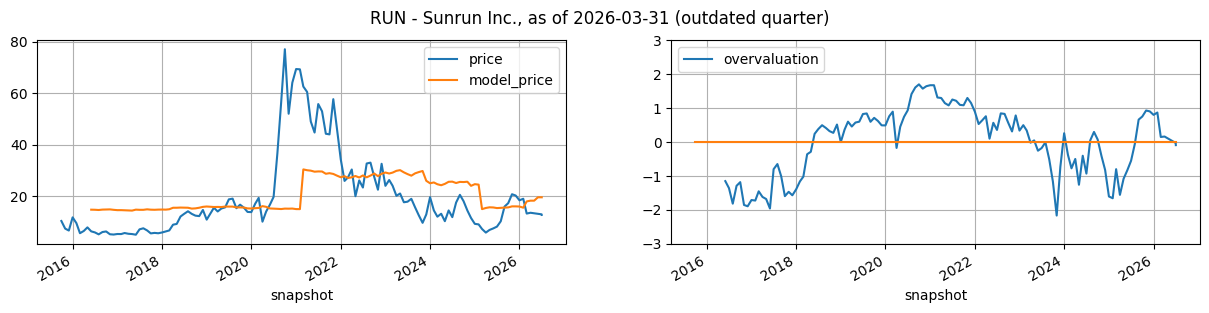

RUN(0001469367) model_price = 3.430472 * (0.950399 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.651555


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,22.610596,19.478112,-0.421440,13.250,0.950399,1.786021,1.258271,3.430472,13.651555,17.968016,0.146811
2026-04-01,2025-12-31,22.610596,19.478112,-0.421440,13.560,0.950399,1.587359,1.341995,3.430472,13.651555,18.255229,0.159923
2026-05-01,2025-12-31,22.610596,19.478112,-0.421440,NaN,0.950399,1.587359,1.341995,3.430472,13.651555,18.255229,NaN
2026-06-01,2026-03-31,22.765093,19.424339,-0.306611,NaN,0.950399,1.587359,1.724876,3.430472,13.651555,19.568694,NaN
2026-07-01,2026-03-31,22.765093,19.424339,-0.306611,NaN,0.950399,1.587359,1.724876,3.430472,13.651555,19.568694,NaN
2026-07-02,2026-03-31,22.765093,19.424339,-0.306611,12.745,0.950399,1.587359,1.724876,3.430472,13.651555,19.568694,-0.092617


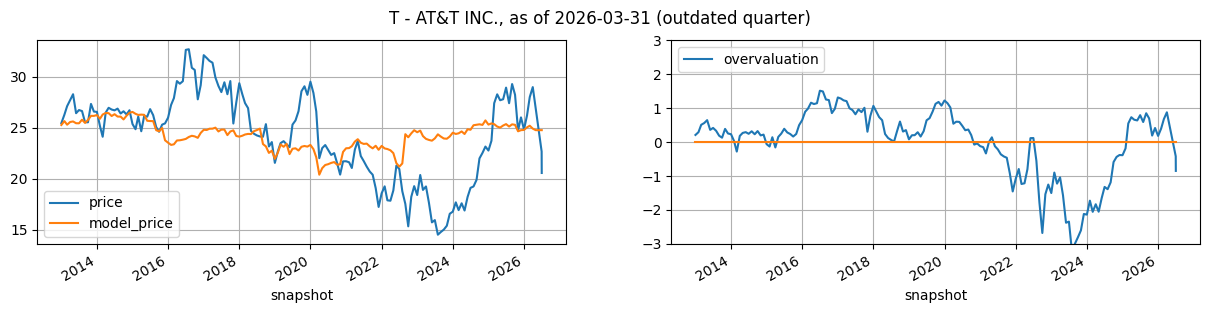

T(0000732717) model_price = 0.035532 * (0.027788 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.666757


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,420.198,293.707,40.284,28.01,0.027788,1.786021,-210.082332,0.035532,32.666757,25.202114,0.671269
2026-04-01,2025-12-31,420.198,293.707,40.284,28.99,0.027788,1.587359,-218.085243,0.035532,32.666757,24.917755,0.872461
2026-05-01,2026-03-31,421.188,295.569,38.792,NaN,0.027788,1.587359,-222.288072,0.035532,32.666757,24.768420,NaN
2026-06-01,2026-03-31,421.188,295.569,38.792,NaN,0.027788,1.587359,-222.288072,0.035532,32.666757,24.768420,NaN
2026-07-01,2026-03-31,421.188,295.569,38.792,NaN,0.027788,1.587359,-222.288072,0.035532,32.666757,24.768420,NaN
2026-07-02,2026-03-31,421.188,295.569,38.792,20.57,0.027788,1.587359,-222.288072,0.035532,32.666757,24.768420,-0.850991


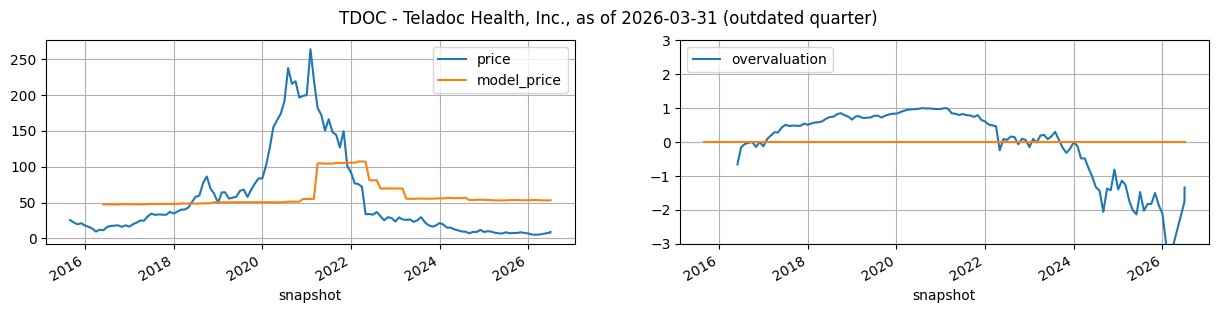

TDOC(0001477449) model_price = 4.317411 * (0.863003 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.040854


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,2.858300,1.472594,0.294357,5.26,0.863003,1.786021,1.519856,4.317411,47.040854,53.602695,-3.189572
2026-04-01,2025-12-31,2.858300,1.472594,0.294357,5.45,0.863003,1.587359,1.461378,4.317411,47.040854,53.350223,-3.021121
2026-05-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.863003,1.587359,1.408816,4.317411,47.040854,53.123293,NaN
2026-06-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.863003,1.587359,1.408816,4.317411,47.040854,53.123293,NaN
2026-07-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.863003,1.587359,1.408816,4.317411,47.040854,53.123293,NaN
2026-07-02,2026-03-31,2.807261,1.470945,0.287954,9.20,0.863003,1.587359,1.408816,4.317411,47.040854,53.123293,-1.337111


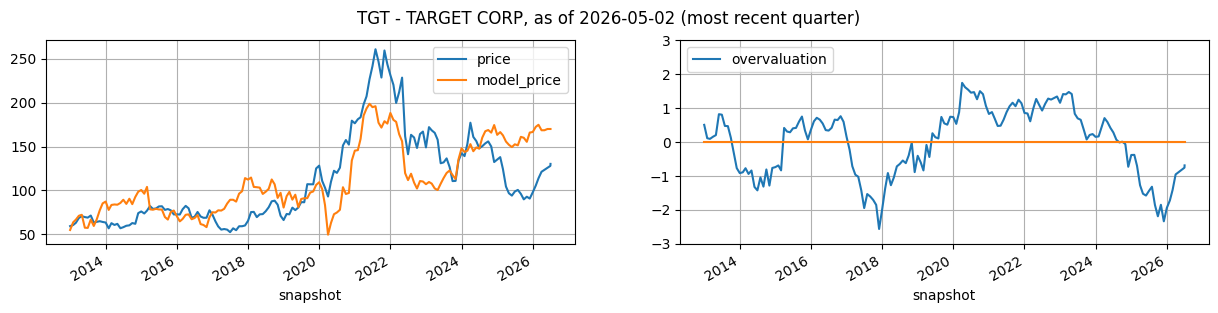

TGT(0000027419) model_price = 5.049766 * (1.435914 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -96.591094


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-11-01,59.991,44.490,6.774,113.79,1.435914,1.786021,53.750406,5.049766,-96.591094,174.835867,-1.410829
2026-04-01,2026-01-31,59.490,43.325,6.562,121.20,1.435914,1.587359,52.513755,5.049766,-96.591094,168.591069,-0.955172
2026-05-01,2026-01-31,59.490,43.325,6.562,NaN,1.435914,1.587359,52.513755,5.049766,-96.591094,168.591069,NaN
2026-06-01,2026-05-02,58.010,41.615,7.003,NaN,1.435914,1.587359,52.798628,5.049766,-96.591094,170.029611,NaN
2026-07-01,2026-05-02,58.010,41.615,7.003,NaN,1.435914,1.587359,52.798628,5.049766,-96.591094,170.029611,NaN
2026-07-02,2026-05-02,58.010,41.615,7.003,130.20,1.435914,1.587359,52.798628,5.049766,-96.591094,170.029611,-0.688586


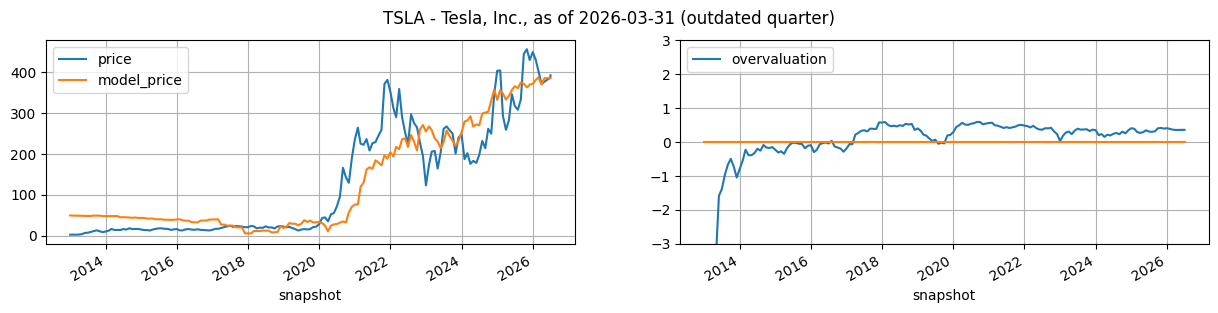

TSLA(0001318605) model_price = 5.878823 * (0.630469 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +49.187690


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,137.806,55.669,14.747,402.5100,0.630469,1.786021,57.551929,5.878823,49.18769,387.525277,0.363038
2026-04-01,2025-12-31,137.806,55.669,14.747,371.7500,0.630469,1.587359,54.622256,5.878823,49.18769,370.302251,0.352960
2026-05-01,2026-03-31,143.724,59.608,16.528,NaN,0.630469,1.587359,57.241461,5.878823,49.18769,385.700091,NaN
2026-06-01,2026-03-31,143.724,59.608,16.528,NaN,0.630469,1.587359,57.241461,5.878823,49.18769,385.700091,NaN
2026-07-01,2026-03-31,143.724,59.608,16.528,NaN,0.630469,1.587359,57.241461,5.878823,49.18769,385.700091,NaN
2026-07-02,2026-03-31,143.724,59.608,16.528,392.8101,0.630469,1.587359,57.241461,5.878823,49.18769,385.700091,0.357255


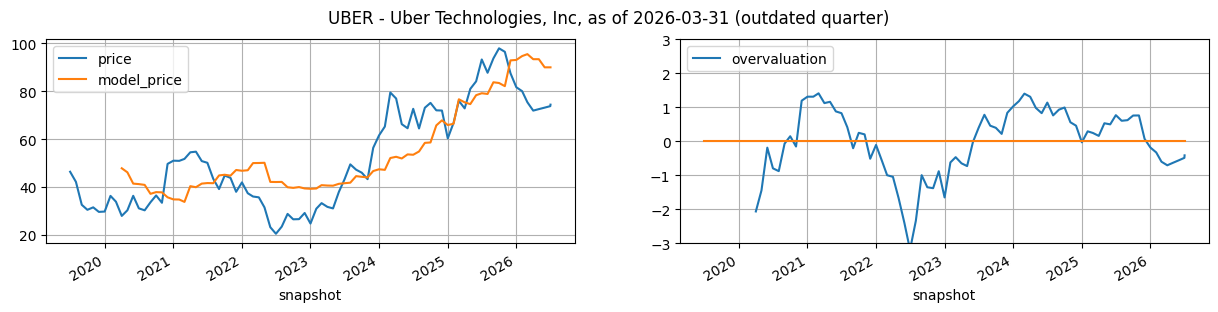

UBER(0001543151) model_price = 1.054581 * (1.509360 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +14.799343


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,61.802,34.761,10.099,75.420,1.50936,1.786021,76.557508,1.054581,14.799343,95.535437,-0.608475
2026-04-01,2025-12-31,61.802,34.761,10.099,71.930,1.50936,1.587359,74.551218,1.054581,14.799343,93.419642,-0.713454
2026-05-01,2025-12-31,61.802,34.761,10.099,NaN,1.50936,1.587359,74.551218,1.054581,14.799343,93.419642,NaN
2026-06-01,2026-03-31,59.885,35.134,10.126,NaN,1.50936,1.587359,71.327633,1.054581,14.799343,90.020110,NaN
2026-07-01,2026-03-31,59.885,35.134,10.126,NaN,1.50936,1.587359,71.327633,1.054581,14.799343,90.020110,NaN
2026-07-02,2026-03-31,59.885,35.134,10.126,74.425,1.50936,1.587359,71.327633,1.054581,14.799343,90.020110,-0.421186


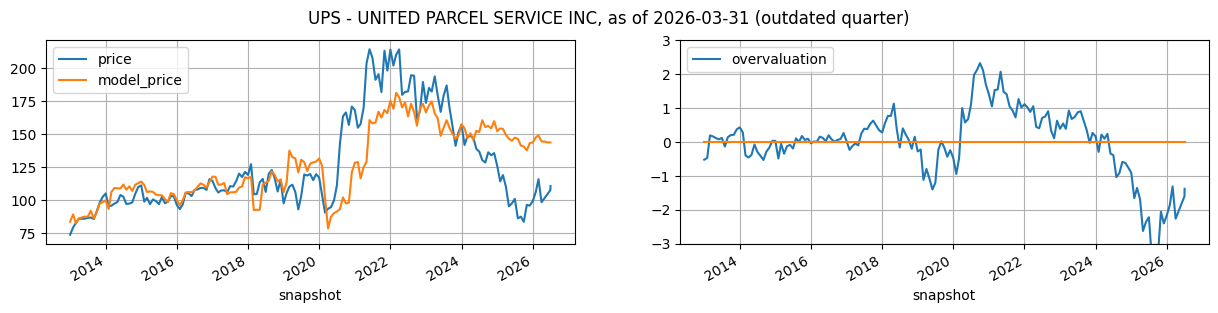

UPS(0001090727) model_price = 2.730263 * (0.730212 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +117.429743


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,73.090,56.863,8.450,115.96,0.730212,1.786021,11.600082,2.730263,117.429743,149.101024,-1.307190
2026-04-01,2025-12-31,73.090,56.863,8.450,98.38,0.730212,1.587359,9.921386,2.730263,117.429743,144.517741,-2.255343
2026-05-01,2025-12-31,73.090,56.863,8.450,NaN,0.730212,1.587359,9.921386,2.730263,117.429743,144.517741,NaN
2026-06-01,2026-03-31,71.809,56.046,8.356,NaN,0.730212,1.587359,9.653773,2.730263,117.429743,143.787086,NaN
2026-07-01,2026-03-31,71.809,56.046,8.356,NaN,0.730212,1.587359,9.653773,2.730263,117.429743,143.787086,NaN
2026-07-02,2026-03-31,71.809,56.046,8.356,110.65,0.730212,1.587359,9.653773,2.730263,117.429743,143.787086,-1.377997


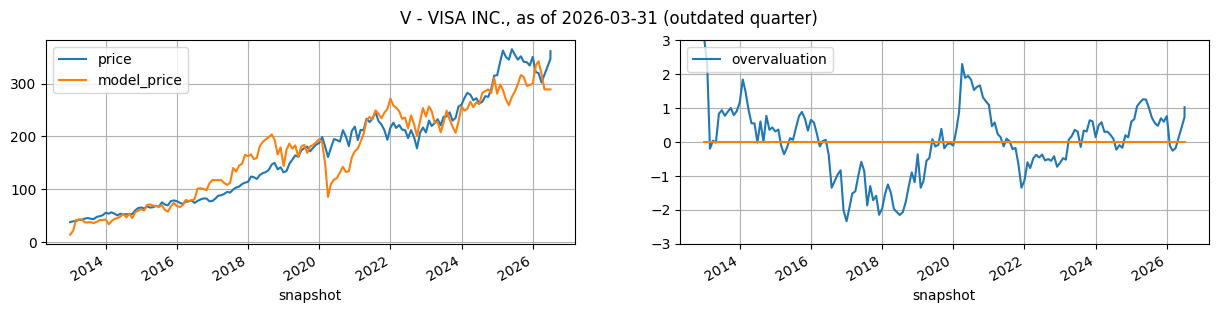

V(0001403161) model_price = 4.944797 * (1.083271 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -104.921408


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,96.814,58.037,24.443,320.14,1.083271,1.786021,90.494486,4.944797,-104.921408,342.555448,-0.256737
2026-04-01,2025-12-31,96.814,58.037,24.443,302.24,1.083271,1.587359,85.638584,4.944797,-104.921408,318.543998,-0.180660
2026-05-01,2026-03-31,95.049,59.388,22.756,NaN,1.083271,1.587359,79.697737,4.944797,-104.921408,289.167714,NaN
2026-06-01,2026-03-31,95.049,59.388,22.756,NaN,1.083271,1.587359,79.697737,4.944797,-104.921408,289.167714,NaN
2026-07-01,2026-03-31,95.049,59.388,22.756,NaN,1.083271,1.587359,79.697737,4.944797,-104.921408,289.167714,NaN
2026-07-02,2026-03-31,95.049,59.388,22.756,361.58,1.083271,1.587359,79.697737,4.944797,-104.921408,289.167714,1.022511


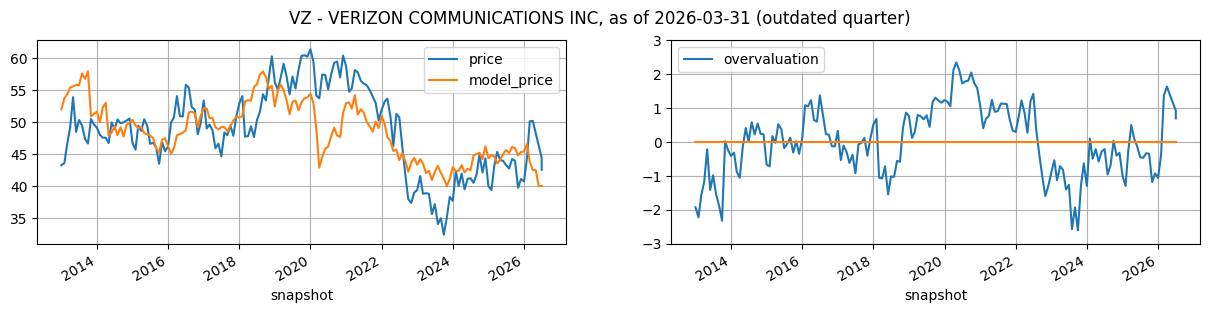

VZ(0000732712) model_price = 0.173552 * (0.005020 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +83.736358


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-12-31,404.258,298.517,37.137,50.140,0.00502,1.786021,-230.160094,0.173552,83.736358,43.791612,1.363656
2026-04-01,2025-12-31,404.258,298.517,37.137,50.200,0.00502,1.587359,-237.537815,0.173552,83.736358,42.511194,1.628806
2026-05-01,2025-12-31,404.258,298.517,37.137,NaN,0.00502,1.587359,-237.537815,0.173552,83.736358,42.511194,NaN
2026-06-01,2026-03-31,417.882,313.260,37.339,NaN,0.00502,1.587359,-251.891774,0.173552,83.736358,40.020035,NaN
2026-07-01,2026-03-31,417.882,313.260,37.339,NaN,0.00502,1.587359,-251.891774,0.173552,83.736358,40.020035,NaN
2026-07-02,2026-03-31,417.882,313.260,37.339,42.555,0.00502,1.587359,-251.891774,0.173552,83.736358,40.020035,0.694104


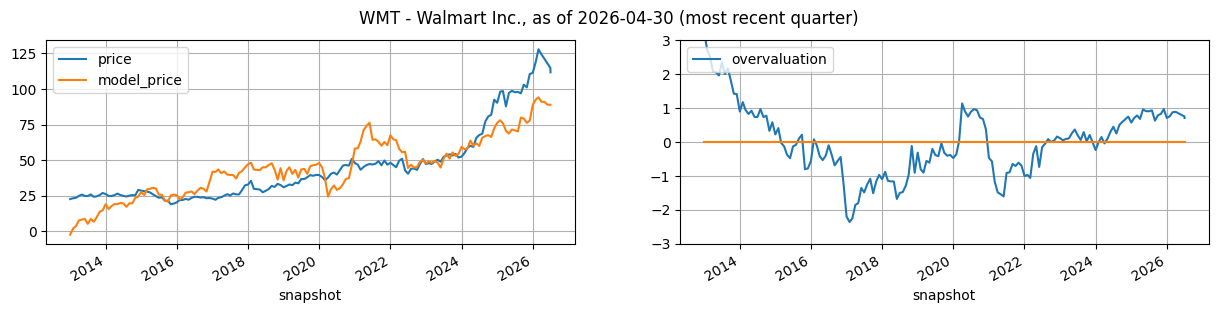

WMT(0000104169) model_price = 0.545440 * (1.530793 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -81.717988


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2025-10-31,288.655,192.561,40.977,127.95,1.530793,1.786021,322.495802,0.54544,-81.717988,94.184062,0.875849
2026-04-01,2026-01-31,284.668,185.051,41.565,124.28,1.530793,1.587359,316.695314,0.54544,-81.717988,91.020244,0.886361
2026-05-01,2026-01-31,284.668,185.051,41.565,NaN,1.530793,1.587359,316.695314,0.54544,-81.717988,91.020244,NaN
2026-06-01,2026-04-30,289.607,195.277,40.892,NaN,1.530793,1.587359,312.961607,0.54544,-81.717988,88.983732,NaN
2026-07-01,2026-04-30,289.607,195.277,40.892,NaN,1.530793,1.587359,312.961607,0.54544,-81.717988,88.983732,NaN
2026-07-02,2026-04-30,289.607,195.277,40.892,111.71,1.530793,1.587359,312.961607,0.54544,-81.717988,88.983732,0.705005


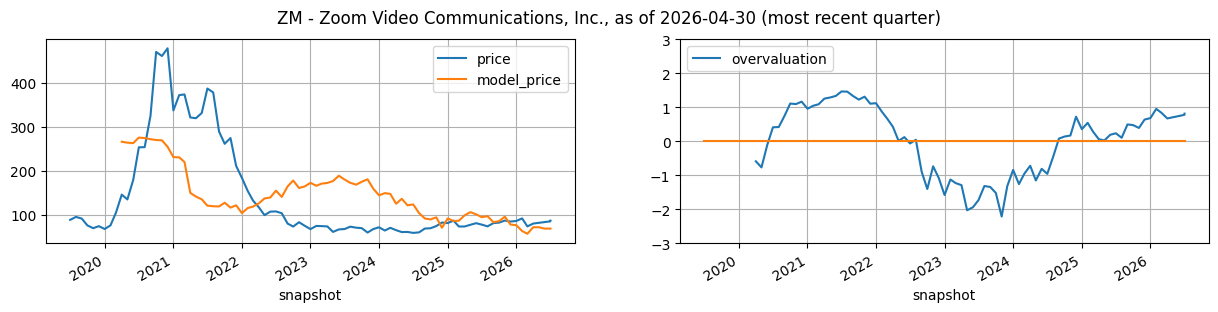

ZM(0001585521) model_price = -37.443761 * (0.345951 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +264.589943


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-03-01,2026-01-31,11.960416,2.152158,1.989048,73.94,0.345951,1.786021,5.538047,-37.443761,264.589943,57.224626,0.830047
2026-04-01,2026-01-31,11.960416,2.152158,1.989048,80.39,0.345951,1.587359,5.142898,-37.443761,264.589943,72.020483,0.664119
2026-05-01,2026-01-31,11.960416,2.152158,1.989048,NaN,0.345951,1.587359,5.142898,-37.443761,264.589943,72.020483,NaN
2026-06-01,2026-04-30,12.162017,2.190869,2.021397,NaN,0.345951,1.587359,5.225281,-37.443761,264.589943,68.935767,NaN
2026-07-01,2026-04-30,12.162017,2.190869,2.021397,NaN,0.345951,1.587359,5.225281,-37.443761,264.589943,68.935767,NaN
2026-07-02,2026-04-30,12.162017,2.190869,2.021397,87.11,0.345951,1.587359,5.225281,-37.443761,264.589943,68.935767,0.806331


In [21]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PRGS","PTON","PYPL",
                "RHI","ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","W","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group

    # Get a ticker fallback name if recent price data is available
    try:
        name = recent_prices.loc[ticker]['name']
    except:
        name = ""

    # Get the default name from the SEC tickers dataset
    try:
        name = tickers.loc[cik]['name']
    except:
        pass

    df = df.reset_index().set_index('snapshot')

    quarters_since_last_report = (datetime.today() - df['date'].max()) / timedelta(days=7) / 13
    caption = f"{ticker} - {name}"
    caption += f", as of {df['date'].max():%Y-%m-%d} ({"most recent" if quarters_since_last_report < 1 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    plot_df = df[['price','model_price','overvaluation']].interpolate(limit_area='inside')
    plot_df[['price','model_price']].plot(ax=ax1, grid=True, legend=True)
    plot_df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3), ylim=(-3,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True).legend(loc='upper left')
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{}({}) model_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, cik, df['hype'].mean(), df['asmul'].mean(),
        "+" if df['bias'].mean() >= 0 else "", df['bias'].mean()
    ))

    # Display a few most recent records from the result set
    display(df.drop(columns=['cik','ticker']).tail(6))

for i in result[result.index.isin(sample_tickers, level='ticker')].groupby(by=['ticker','cik']):
    plot_ticker(i)
    display(HTML("<hr>"))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together, as shown below. An interesting observaton here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued.

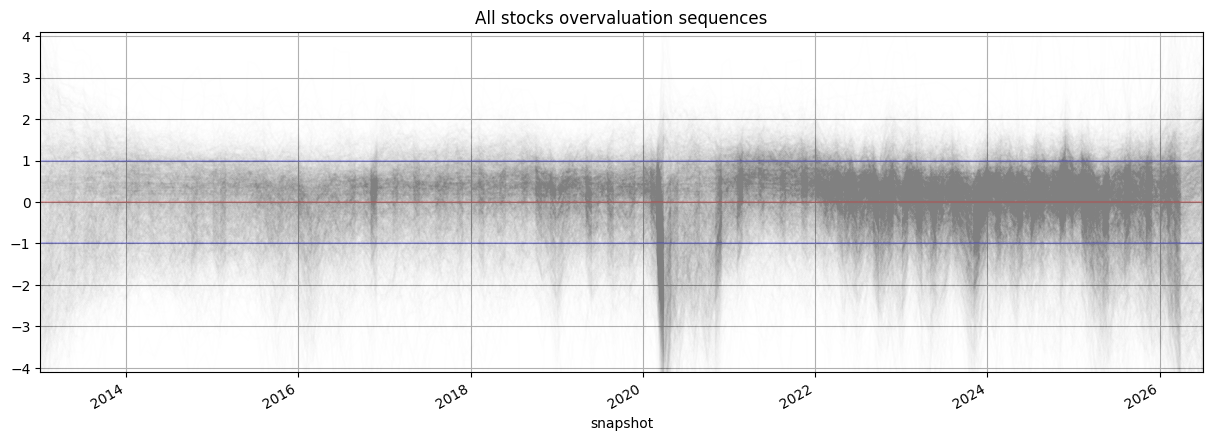

CPU times: user 8.31 s, sys: 61.9 ms, total: 8.37 s
Wall time: 8.33 s


In [22]:
%%time
def plot_overvaluations(df):
    overvaluations = pd.pivot_table(df, index='snapshot', columns='ticker', values='overvaluation', dropna=False).interpolate(limit_area='inside').dropna(how='all')
    x_lim = sorted(overvaluations.index.to_frame().agg(['min','max']).iloc[:,0].to_list())
    horizontal_ticks = [-1,0,1]
    horizontal_lines = pd.DataFrame([horizontal_ticks]*len(overvaluations.index), index=overvaluations.index, columns=horizontal_ticks)
    ax = overvaluations.plot(figsize=(15,5), title='All stocks overvaluation sequences', xlim=x_lim, ylim=(-4.1,4.1), grid=True, legend=False, c='grey', alpha=0.005 )
    horizontal_lines[0].plot(ax=ax, grid=True, c='red', alpha=0.2, legend=False)
    horizontal_lines.drop(columns=[0]).plot(ax=ax, grid=True, c='blue', alpha=0.2, legend=False)
    return ax
plot_overvaluations(result)
plt.show()

In [23]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.